# 01 — Exploratory Data Analysis: Weekly Unit Demand

## Purpose
Load the Power BI semantic model exports, diagnose data quality, characterize the
panel structure (store × division × week), assess modeling readiness, and produce
a clean weekly unit demand table for the forecasting pipeline.

**Every section in this notebook either:**
1. Drives a downstream modeling decision (NB02–04)
2. Provides a client-facing insight
3. Raises a question for the client

## Notebook Structure

| # | Section | Purpose |
|---|---------|--------|
| 1 | Setup & Data Loading | Load slices, fiscal calendar, store master |
| 2 | Data Cleaning & Exclusions | Remove junk, detect test/liquidation stores |
| 3 | Store Coverage Analysis | Coverage gaps, anomalous stores, missing stores |
| 4 | Division Breakdown | Product divisions, sparsity, heatmap |
| 5 | Units vs Revenue | Client decision point — what are we forecasting? |
| 6 | Returns & Data Quality | Return rates by division/store |
| 7 | Weekly Aggregation | Build target variable, save output |
| 8 | Seasonality & Demand Patterns | Client-facing seasonal insights |
| 9 | Panel Sparsity & Modeling Tiers | Data availability by group |
| 10 | Modeling Readiness Assessment | Intermittency, seasonality strength, lag validation |
| 11 | Questions for Client | Numbered list for client follow-up |
| A | Appendix: Technical Diagnostics | Stationarity tests, ACF/PACF, outlier detection |

## Data Source
Export from **V2_STATISTIQUES** semantic model (Power BI), sliced per store.
Each slice file contains transaction-level records with:

| Column | Role |
|--------|------|
| `Date de Vente` | Transaction date |
| `Magasins` / `No. magasin` | Store code (e.g., "CP01 - Québec") |
| `Division Code corrigée` | Product division code (internal ERP) |
| `Quantité facturée` | **Target variable** — units sold |

## Key Assumptions
1. **Fiscal year**: Nov 1 – Oct 31 (FY2024 = Nov 2023 – Oct 2024). Aligned via `Table Calendrier.xlsx`.
2. **Returns**: Negative quantities = returns. Netted at weekly level; net units clipped to 0.
3. **Zero-demand weeks**: Absent from output (not zero-filled). Downstream models handle implicit zeros.

## Outputs
- `data/processed/weekly_units.csv` — weekly unit demand by store × division
- `data/processed/store_region_map.csv` — store metadata (city, province, franchise, POS)
- `data/processed/demand_intermittency.csv` — ADI/CV² classification per series

---
## Section 1 — Setup & Data Loading
---

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 80)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_palette('husl')

PROJECT_ROOT   = Path('..')
DATA_RAW       = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES        = PROJECT_ROOT / 'reports' / 'figures'
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# Power BI adds these junk rows to every export
PBI_JUNK = [
    'Total',
    'No filters applied',
    'Exported data exceeded the allowed volume. Some data may have been omitted.'
]

# Fiscal month order for charts (Nov=1st month of FY, Oct=12th)
FISCAL_MONTH_ORDER  = [11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
FISCAL_MONTH_LABELS = ['Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct']

print('Setup complete')

Setup complete


### Load Fiscal Calendar

The client's official fiscal calendar (`Table Calendrier.xlsx`) maps every calendar date
to its fiscal year, fiscal month, fiscal quarter, and fiscal week. This is the **single
source of truth** for all time-based alignment in the pipeline.

In [40]:
cal = pd.read_excel(DATA_RAW / 'Table Calendrier.xlsx', usecols=[
    'Date', 'FiscalYear', 'FiscalMonthNum', 'FiscalQuarter',
    '_Semaine fiscale NEW', 'Fin de semaine'
])
cal['Date'] = pd.to_datetime(cal['Date'])
cal = cal.rename(columns={
    'FiscalYear': 'fiscal_year_label',
    'FiscalMonthNum': 'fiscal_month',
    'FiscalQuarter': 'fiscal_quarter',
    '_Semaine fiscale NEW': 'fiscal_week',
    'Fin de semaine': 'cal_week_ending',
})
cal['fiscal_year'] = cal['fiscal_year_label'].str.extract(r'(\d{4})').astype(int)
cal['cal_week_ending'] = pd.to_datetime(cal['cal_week_ending'])

print(f'Table Calendrier: {len(cal):,} days')
print(f'Date range: {cal["Date"].min().date()} -> {cal["Date"].max().date()}')
print(f'Fiscal years: {sorted(cal["fiscal_year"].unique())}')
print(f'Fiscal weeks per FY:')
print(cal.groupby('fiscal_year')['fiscal_week'].max().to_string())

Table Calendrier: 1,096 days
Date range: 2023-11-01 -> 2026-10-31
Fiscal years: [np.int64(2024), np.int64(2025), np.int64(2026)]
Fiscal weeks per FY:
fiscal_year
2024    53
2025    52
2026    52


### Load Store Slice Exports

Each store has a separate `.xlsx` file exported from the Power BI semantic model.
These contain transaction-level records: date, store, division code, and quantity billed.

> **Note**: Files prefixed with `~$` are Excel lock files and are automatically excluded.

In [41]:
SLICES_DIR = DATA_RAW / 'slices'
files = sorted([f for f in SLICES_DIR.glob('*.xlsx') if not f.name.startswith('~$')])
files += sorted([f for f in SLICES_DIR.glob('*.csv') if not f.name.startswith('~$')])
print(f'Found {len(files)} slice files (excluding lock files)')
for f in files:
    print(f'  {f.name}')

slices = []
for i, f in enumerate(files):
    print(f'  Loading {f.name}... ({i+1}/{len(files)})', end='\r')
    s = pd.read_excel(f) if f.suffix == '.xlsx' else pd.read_csv(f)
    s = s[~s['Magasins'].isin(PBI_JUNK)].copy()
    slices.append(s)

print(f'  Loaded {len(files)} files.{" " * 30}')

raw = pd.concat(slices, ignore_index=True).drop_duplicates()
raw['Date de Vente']          = pd.to_datetime(raw['Date de Vente'], errors='coerce')
raw['Quantité facturée']      = pd.to_numeric(raw['Quantité facturée'], errors='coerce')
raw['No. magasin']            = raw['Magasins'].astype(str).str.strip()
raw['Division Code corrigée'] = raw['Division Code corrigée'].astype(str).str.strip()
raw = raw.dropna(subset=['Date de Vente', 'Quantité facturée'])

# Merge fiscal year from Table Calendrier
raw = raw.merge(
    cal[['Date','fiscal_year','fiscal_month','fiscal_quarter','fiscal_week']],
    left_on='Date de Vente', right_on='Date', how='left'
).drop(columns=['Date'])

unmatched = raw['fiscal_year'].isna().sum()
if unmatched > 0:
    print(f'WARNING: {unmatched} rows have dates outside Table Calendrier range')
raw['fiscal_year'] = raw['fiscal_year'].astype('Int64')

print(f'\n=== Raw Data Summary ===')
print(f'Total rows       : {len(raw):,}')
print(f'Columns          : {list(raw.columns)}')
print(f'Date range       : {raw["Date de Vente"].min().date()} -> {raw["Date de Vente"].max().date()}')
print(f'Unique stores    : {raw["No. magasin"].nunique()}')
print(f'Unique divisions : {raw["Division Code corrigée"].nunique()}')
print(f'\nFiscal year breakdown:')
fy_summary = (
    raw.groupby('fiscal_year')
       .agg(start=('Date de Vente','min'), end=('Date de Vente','max'),
            rows=('Quantité facturée','count'), total_units=('Quantité facturée','sum'))
)
fy_summary['start'] = fy_summary['start'].dt.date
fy_summary['end']   = fy_summary['end'].dt.date
print(fy_summary.to_string())
print(f'\nSample rows:')
raw[['Date de Vente','No. magasin','Division Code corrigée','Quantité facturée',
     'fiscal_year','fiscal_week']].head(10)

Found 32 slice files (excluding lock files)
  CP01.xlsx
  CP02.xlsx
  CP04.xlsx
  CP05.xlsx
  CP06.xlsx
  CP07.xlsx
  CP08.xlsx
  CP10.xlsx
  CP11.xlsx
  CP12.xlsx
  CP13.xlsx
  CP15.xlsx
  CP16.xlsx
  CP17.xlsx
  CP18.xlsx
  CP20.xlsx
  CP202.xlsx
  CP28.xlsx
  CP29.xlsx
  CP32.xlsx
  CP33.xlsx
  CP35.xlsx
  CP36.xlsx
  CP37.xlsx
  CP39.xlsx
  CP40.xlsx
  CP43.xlsx
  CP44.xlsx
  CP45.xlsx
  CP46.xlsx
  CP47.xlsx
  CP48.xlsx
  Loaded 32 files.                              

=== Raw Data Summary ===
Total rows       : 204,236
Columns          : ['Date de Vente', 'Quantité facturée', 'Division Code corrigée', 'Magasins', 'No. magasin', 'fiscal_year', 'fiscal_month', 'fiscal_quarter', 'fiscal_week']
Date range       : 2023-11-02 -> 2026-03-10
Unique stores    : 32
Unique divisions : 35

Fiscal year breakdown:
                  start         end    rows  total_units
fiscal_year                                             
2024         2023-11-02  2024-10-31   78780   2812587.04
2025       

,Date de Vente,No. magasin,Division Code corrigée,Quantité facturée,fiscal_year,fiscal_week
0,2024-03-27,CP01 - Québec,GA,1.0,2024,22
1,2024-04-06,CP01 - Québec,ME,2.0,2024,23
2,2024-04-09,CP01 - Québec,ME,1.0,2024,24
3,2024-04-10,CP01 - Québec,GA,2.0,2024,24
4,2024-04-21,CP01 - Québec,ME,9.0,2024,25
5,2024-05-14,CP01 - Québec,AP,109.0,2024,29
6,2024-05-14,CP01 - Québec,CH,1.0,2024,29
7,2024-05-14,CP01 - Québec,CR,1.0,2024,29
8,2024-05-14,CP01 - Québec,PI,5.0,2024,29
9,2024-05-19,CP01 - Québec,AS,3.0,2024,29


---
## Section 2 — Data Cleaning & Exclusions

### Exclusion logic
1. **Junk rows**: Remove Power BI export artifacts (`Total`, `No filters applied`, etc.)
2. **Liquidation stores**: Detected by name pattern (case-insensitive search for "liquidation")
3. **Test/placeholder stores**: Stores with < 10 weeks of data are assumed to be test entries or incomplete exports. Threshold rationale: 10 weeks is well below 1 quarter (13 weeks), making this a conservative minimum.

### Why this matters
Including test or closing stores would contaminate the demand signal with artificial patterns.
The diagnostic table below shows ALL stores before exclusion so the decision is transparent.

---

In [42]:
# ── Step 1: Remove obvious junk rows ──────────────────────────────────────────
raw = raw[raw['No. magasin'] != 'nan'].copy()
raw = raw[raw['Division Code corrigée'] != 'nan'].copy()

# ── Step 2: Detect liquidation stores by name pattern ─────────────────────────
all_stores = raw['No. magasin'].unique()
liquidation_stores = [s for s in all_stores if 'liquidation' in s.lower()]
print(f'Liquidation stores detected: {liquidation_stores if liquidation_stores else "None"}')

# ── Step 3: Detect test/placeholder stores by data volume ─────────────────────
raw['week_ending_tmp'] = raw['Date de Vente'] + pd.offsets.Week(weekday=6)
store_diagnostics = (
    raw.groupby('No. magasin')
       .agg(
           n_weeks       = ('week_ending_tmp', 'nunique'),
           n_rows        = ('Quantité facturée', 'count'),
           total_units   = ('Quantité facturée', 'sum'),
           median_weekly  = ('Quantité facturée', 'median'),
           n_divisions   = ('Division Code corrigée', 'nunique'),
           first_date    = ('Date de Vente', 'min'),
           last_date     = ('Date de Vente', 'max'),
       )
       .sort_values('n_weeks', ascending=True)
)
store_diagnostics['first_date'] = store_diagnostics['first_date'].dt.date
store_diagnostics['last_date']  = store_diagnostics['last_date'].dt.date
store_diagnostics['total_units'] = store_diagnostics['total_units'].round(0).astype(int)

test_stores = store_diagnostics[store_diagnostics['n_weeks'] < 10].index.tolist()
print(f'Test/placeholder stores (< 10 weeks): {test_stores if test_stores else "None"}')

# ── Step 4: Show FULL diagnostic table ────────────────────────────────────────
print(f'\n{"=" * 80}')
print(f'STORE DIAGNOSTIC TABLE — ALL {len(store_diagnostics)} STORES (sorted by weeks ascending)')
print(f'{"=" * 80}')
pd.set_option('display.max_rows', 50)
print(store_diagnostics.to_string())

# Network averages for comparison
avg_weeks = store_diagnostics['n_weeks'].mean()
avg_units = store_diagnostics['total_units'].mean()
print(f'\nNetwork averages: {avg_weeks:.0f} weeks, {avg_units:,.0f} total units')

# ── Step 5: Apply exclusions ──────────────────────────────────────────────────
EXCLUDE_STORES = list(set(liquidation_stores + test_stores))
raw = raw[~raw['No. magasin'].isin(EXCLUDE_STORES)].copy()
raw = raw.drop(columns=['week_ending_tmp'])

print(f'\n{"=" * 80}')
print(f'EXCLUSION SUMMARY')
print(f'{"=" * 80}')
if EXCLUDE_STORES:
    for s in sorted(EXCLUDE_STORES):
        reason = 'Liquidation store' if s in liquidation_stores else 'Insufficient data (< 10 weeks)'
        print(f'  EXCLUDED: {s} — {reason}')
else:
    print('  No stores excluded (all have >= 10 weeks of data)')

print(f'\nAfter cleaning : {len(raw):,} rows')
print(f'Stores         : {raw["No. magasin"].nunique()}')
print(f'Divisions      : {raw["Division Code corrigée"].nunique()}')
print(f'Negative units : {int((raw["Quantité facturée"] < 0).sum()):,}  (returns — kept, netted at weekly level)')

Liquidation stores detected: None
Test/placeholder stores (< 10 weeks): None

STORE DIAGNOSTIC TABLE — ALL 32 STORES (sorted by weeks ascending)
                                 n_weeks  n_rows  total_units  median_weekly  n_divisions  first_date   last_date
No. magasin                                                                                                      
CP40 - Thetford Mines                 70    2351       671734            3.0           21  2024-09-12  2026-03-06
CP12 - St-Georges-de-Beauce           71    3014        74563            3.0           24  2024-11-01  2026-03-06
CP18 - Val-d'Or                       75    2282        35163            2.0           23  2024-05-11  2026-03-05
CP05 - Sherbrooke                     81    5807       520875            6.0           26  2024-05-02  2026-03-06
CP47 - Riviere-du-Loup                83    3435        71827            3.0           26  2024-07-04  2026-03-09
CP20 - Valleyfield                    88    3267      343

---
## Section 3 — Store Coverage Analysis

### Why this matters
Uneven store coverage directly affects forecast reliability. Stores with < 52 weeks
cannot support annual seasonality models. This section identifies coverage gaps
and flags anomalies for client discussion.

---

In [43]:
# ── Load Table_Magasins ───────────────────────────────────────────────────────
store_master = pd.read_excel(DATA_RAW / 'Table_Magasins.xlsx')
store_master = store_master[
    ~store_master['Magasins'].str.contains('Entrepôt|Siège social|Démo', case=False, na=False)
].copy()
print(f'Table_Magasins: {len(store_master)} retail stores (excluding warehouses, HQ, demo)')

# Prepare store master for merge (rename to avoid column collision with raw 'Magasins')
store_info = store_master[['Magasins', 'Ville magasins', 'Regroupement',
                           'Nom Regroupement', 'Système informatique']].copy()
store_info = store_info.rename(columns={
    'Magasins': 'store_key',
    'Ville magasins': 'city',
    'Regroupement': 'franchise_group',
    'Nom Regroupement': 'franchise_name',
    'Système informatique': 'pos_system',
})

raw = raw.merge(store_info, left_on='No. magasin', right_on='store_key', how='left')
raw = raw.drop(columns=['store_key'], errors='ignore')
raw['province'] = np.where(raw['No. magasin'].str.startswith('CP202'), 'ON', 'QC')

# Save store region map
store_map = (
    raw[['No. magasin','city','province','franchise_group','franchise_name','pos_system']]
    .drop_duplicates()
    .rename(columns={'No. magasin':'store_code'})
    .sort_values('store_code').reset_index(drop=True)
)
store_map.to_csv(DATA_PROCESSED / 'store_region_map.csv', index=False)
print(f'\nSaved: store_region_map.csv ({len(store_map)} stores)')
print(f'\n{store_map.to_string(index=False)}')

Table_Magasins: 41 retail stores (excluding warehouses, HQ, demo)

Saved: store_region_map.csv (32 stores)

                     store_code                     city province franchise_group                  franchise_name             pos_system
                  CP01 - Québec                   Québec       QC            CP01                   CP01 - Québec              Home made
              CP02 - Blainville               Blainville       QC            CP07                    CP07 - Laval Meublex V27 (Informat)
           CP04 - Drummondville            Drummondville       QC            CP04            CP04 - Drummondville                    NAV
              CP05 - Sherbrooke               Sherbrooke       QC            CP05               CP05 - Sherbrooke                Accomba
                  CP06 - Granby                   Granby       QC            CP06                   CP06 - Granby Meublex V27 (Informat)
                   CP07 - Laval                    Laval       QC     

### 3b — Missing Stores

Which stores from the client's master list have **no data** in our slice exports?

In [44]:
all_master_stores = set(store_master['Magasins'].str.strip())
all_data_stores = set(raw['No. magasin'].unique())
missing_stores = sorted(all_master_stores - all_data_stores)

if missing_stores:
    print(f'MISSING STORES: {len(missing_stores)} retail stores in Table_Magasins have NO slice data')
    print(f'{"=" * 60}')
    for s in missing_stores:
        city = store_master.loc[store_master['Magasins'].str.strip() == s, 'Ville magasins'].values
        city = city[0] if len(city) > 0 else '?'
        print(f'  {s} ({city})')
    print(f'\n> CLIENT QUESTION: Are slice exports available for these stores?')
    print(f'> Are they active stores, or closed/not yet connected to Power BI?')
else:
    print('All stores from Table_Magasins are present in slice data.')

MISSING STORES: 9 retail stores in Table_Magasins have NO slice data
  CP03 - Brossard (Brossard)
  CP100 - Liquidation (Saint-Jérôme)
  CP21 - Rimouski (Rimouski)
  CP23 - Terrebonne (Terrebonne)
  CP31 - Pierrefonds (Pierrefonds)
  CP41 - St-Hubert (St-Hubert)
  CP49 - Bonaventure (Bonaventure)
  CP50 - Rouyn-Noranda (Rouyn-Noranda)
  CP77 - Liquidation (Liquidation)

> CLIENT QUESTION: Are slice exports available for these stores?
> Are they active stores, or closed/not yet connected to Power BI?


### 3c — Per-Store Coverage & Anomalies

In [45]:
raw['week_ending'] = raw['Date de Vente'] + pd.offsets.Week(weekday=6)
total_weeks = raw['week_ending'].nunique()

# Per-store coverage table
store_cov = (
    raw.groupby('No. magasin')
       .agg(
           n_weeks      = ('week_ending', 'nunique'),
           total_units  = ('Quantité facturée', lambda x: x[x > 0].sum()),
           n_divisions  = ('Division Code corrigée', 'nunique'),
           first_date   = ('Date de Vente', 'min'),
           last_date    = ('Date de Vente', 'max'),
       )
       .sort_values('n_weeks', ascending=True)
       .reset_index()
)
store_cov['first_date'] = store_cov['first_date'].dt.date
store_cov['last_date']  = store_cov['last_date'].dt.date
store_cov['total_units'] = store_cov['total_units'].round(0).astype(int)
store_cov['pct_coverage'] = (store_cov['n_weeks'] / total_weeks * 100).round(1)

print(f'Total weeks in dataset: {total_weeks}')
print(f'\nPer-Store Coverage (sorted by weeks ascending):')
print(f'{"=" * 90}')
print(store_cov.to_string(index=False))

# Flag stores with < 52 weeks
low_cov = store_cov[store_cov['n_weeks'] < 52]
if len(low_cov) > 0:
    print(f'\nSTORES WITH < 52 WEEKS ({len(low_cov)}):')
    for _, row in low_cov.iterrows():
        print(f'  {row["No. magasin"]}: {row["n_weeks"]} weeks '
              f'({row["first_date"]} to {row["last_date"]}), '
              f'{row["total_units"]:,} units, {row["n_divisions"]} divisions')
    print(f'\n> CLIENT QUESTION: Are these stores newer (opened mid-period), '
          f'or is this a POS export issue?')

Total weeks in dataset: 124

Per-Store Coverage (sorted by weeks ascending):
                    No. magasin  n_weeks  total_units  n_divisions first_date  last_date  pct_coverage
          CP40 - Thetford Mines       70       671965           21 2024-09-12 2026-03-06          56.5
    CP12 - St-Georges-de-Beauce       71        74742           24 2024-11-01 2026-03-06          57.3
                CP18 - Val-d'Or       75        35510           23 2024-05-11 2026-03-05          60.5
              CP05 - Sherbrooke       81       522456           26 2024-05-02 2026-03-06          65.3
         CP47 - Riviere-du-Loup       83        73722           26 2024-07-04 2026-03-09          66.9
             CP20 - Valleyfield       88      3443920           19 2024-04-16 2026-03-06          71.0
                   CP29 - Lévis       93        68327           20 2024-03-06 2026-03-01          75.0
                 CP43 - Ste-Foy       94        89310           19 2024-02-11 2026-03-08          7

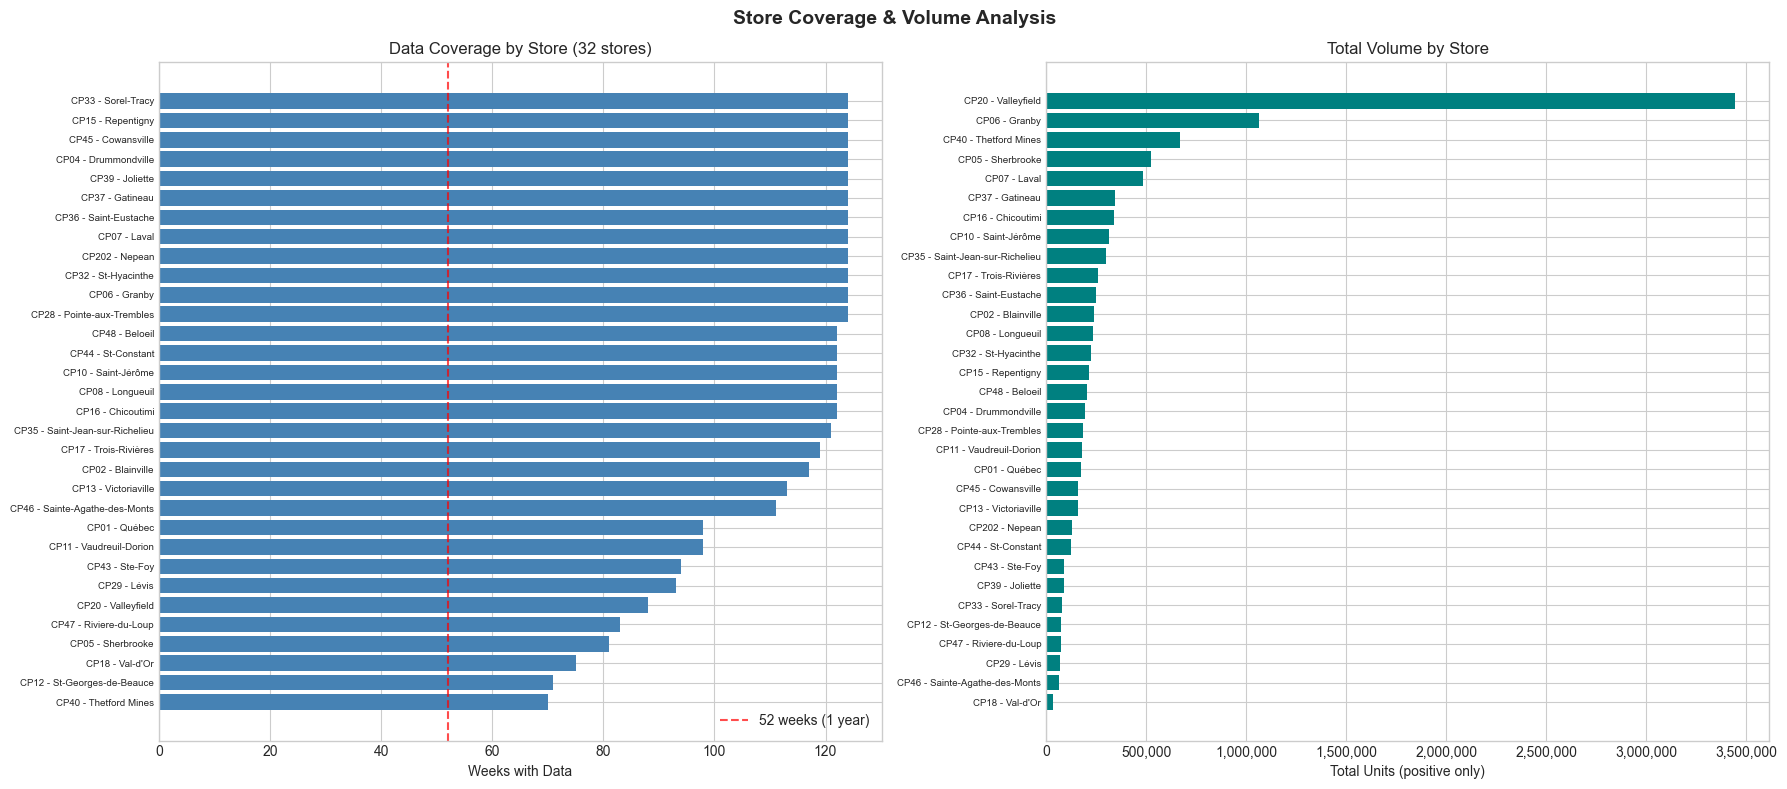

Stores with < 52 weeks: 0
Stores with >= 52 weeks: 32


In [46]:
# ── Store coverage bar chart ──────────────────────────────────────────────────
store_cov_sorted = store_cov.sort_values('n_weeks', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Coverage by weeks
colors = ['salmon' if w < 52 else 'steelblue' for w in store_cov_sorted['n_weeks']]
axes[0].barh(store_cov_sorted['No. magasin'], store_cov_sorted['n_weeks'], color=colors)
axes[0].axvline(x=52, color='red', linestyle='--', alpha=0.7, label='52 weeks (1 year)')
axes[0].set_xlabel('Weeks with Data')
axes[0].set_title(f'Data Coverage by Store ({len(store_cov)} stores)')
axes[0].legend()
axes[0].tick_params(axis='y', labelsize=7)

# Total units by store (identify volume outliers)
store_vol = store_cov.sort_values('total_units', ascending=True)
axes[1].barh(store_vol['No. magasin'], store_vol['total_units'], color='teal')
axes[1].set_xlabel('Total Units (positive only)')
axes[1].set_title('Total Volume by Store')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))
axes[1].tick_params(axis='y', labelsize=7)

plt.suptitle('Store Coverage & Volume Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'store_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Stores with < 52 weeks: {(store_cov["n_weeks"] < 52).sum()}')
print(f'Stores with >= 52 weeks: {(store_cov["n_weeks"] >= 52).sum()}')

### 3d — POS System & Franchise Group Patterns

Does the POS system (Bell vs Accomba) correlate with data quality or coverage?
Do stores within the same franchise group have similar demand patterns?

In [47]:
# Merge store metadata onto coverage table
store_cov_meta = store_cov.merge(
    store_map.rename(columns={'store_code': 'No. magasin'}),
    on='No. magasin', how='left'
)

# POS system breakdown
print('=== Coverage by POS System ===')
pos_summary = store_cov_meta.groupby('pos_system').agg(
    n_stores     = ('No. magasin', 'count'),
    avg_weeks    = ('n_weeks', 'mean'),
    min_weeks    = ('n_weeks', 'min'),
    avg_units    = ('total_units', 'mean'),
    avg_divisions = ('n_divisions', 'mean'),
).round(1)
print(pos_summary.to_string())

# Franchise group breakdown
print(f'\n=== Coverage by Franchise Group ===')
fran_summary = store_cov_meta.groupby(['franchise_group', 'franchise_name']).agg(
    stores    = ('No. magasin', lambda x: ', '.join(sorted(x))),
    n_stores  = ('No. magasin', 'count'),
    avg_weeks = ('n_weeks', 'mean'),
    avg_units = ('total_units', 'mean'),
).round(0)
print(fran_summary.to_string())

# Anomalous stores investigation: CP05, CP20, CP40
print(f'\n=== Anomalous Store Investigation ===')
anomalous = ['CP05 - Sherbrooke', 'CP20 - Valleyfield', 'CP40 - Thetford Mines']
for store_name in anomalous:
    match = store_cov_meta[store_cov_meta['No. magasin'].str.contains(store_name.split(' - ')[0])]
    if len(match) > 0:
        row = match.iloc[0]
        print(f'\n  {row["No. magasin"]}:')
        print(f'    Weeks: {row["n_weeks"]} (network avg: {store_cov["n_weeks"].mean():.0f})')
        print(f'    Units: {row["total_units"]:,} (network avg: {store_cov["total_units"].mean():,.0f})')
        print(f'    Divisions: {row["n_divisions"]} (network avg: {store_cov["n_divisions"].mean():.0f})')
        print(f'    POS: {row["pos_system"]}, Franchise: {row["franchise_name"]}')
        print(f'    Coverage: {row["first_date"]} to {row["last_date"]}')

=== Coverage by POS System ===
                        n_stores  avg_weeks  min_weeks  avg_units  avg_divisions
pos_system                                                                      
Accomba                        5       76.0         70   275679.0           24.0
Home made                      3       95.0         93   111085.7           20.0
Integratik                     2       93.0         88  1811110.5           20.5
Meublex V27 (Informat)         9      123.0        117   357088.2           22.9
NAV                           13      120.9        111   188102.1           26.9

=== Coverage by Franchise Group ===
                                                                                                                             stores  n_stores  avg_weeks  avg_units
franchise_group franchise_name                                                                                                                                     
CP01            CP01 - Québec        

---
## Section 4 — Division Breakdown

### Why this matters
- Division codes are **internal ERP identifiers** — we need the client to provide a mapping to product names
- Not all divisions are in all stores — understanding which divisions are sparse helps model selection
- The division mix tells us which product lines drive the most volume

---

In [48]:
# Full division summary
div_summary = (
    raw.groupby('Division Code corrigée')
       .agg(
           total_units    = ('Quantité facturée', lambda x: x[x > 0].sum()),
           transactions   = ('Quantité facturée', 'count'),
           avg_units_per_tx = ('Quantité facturée', 'mean'),
           n_stores       = ('No. magasin', 'nunique'),
           n_weeks        = ('week_ending', 'nunique'),
       )
       .sort_values('total_units', ascending=False).reset_index()
)
div_summary['pct_units'] = (div_summary['total_units'] / div_summary['total_units'].sum() * 100).round(1)
div_summary['avg_units_per_tx'] = div_summary['avg_units_per_tx'].round(2)
div_summary['total_units'] = div_summary['total_units'].round(0).astype(int)

print(f'=== Division Summary ({len(div_summary)} divisions) ===')
print(f'\n> NOTE: Division codes are internal ERP identifiers.')
print(f'> CLIENT ACTION: Please provide a mapping of these codes to product line names.\n')
print(div_summary.to_string(index=False))

# Flag sparse divisions
sparse_divs = div_summary[(div_summary['n_stores'] < 5) | (div_summary['n_weeks'] < 26)]
if len(sparse_divs) > 0:
    print(f'\nSPARSE DIVISIONS (< 5 stores or < 26 weeks): {len(sparse_divs)}')
    print(sparse_divs[['Division Code corrigée','n_stores','n_weeks','pct_units']].to_string(index=False))
    print(f'\n> CLIENT QUESTION: Are these real product lines or internal/test codes?')

=== Division Summary (34 divisions) ===

> NOTE: Division codes are internal ERP identifiers.
> CLIENT ACTION: Please provide a mapping of these codes to product line names.

Division Code corrigée  total_units  transactions  avg_units_per_tx  n_stores  n_weeks  pct_units
                    AP      4592336         18704            245.09        32      124       41.8
                    PC      2474090         20801            118.93        32      124       22.5
                    PI       778586         17444             44.58        32      124        7.1
                    DI       676355          2988            225.56        25      124        6.2
                    SE       645661         10615             60.36        28      124        5.9
                    AZ       455324          5572             81.47        25      123        4.1
                    AS       329815         17734             18.58        32      124        3.0
                    IN       316576      

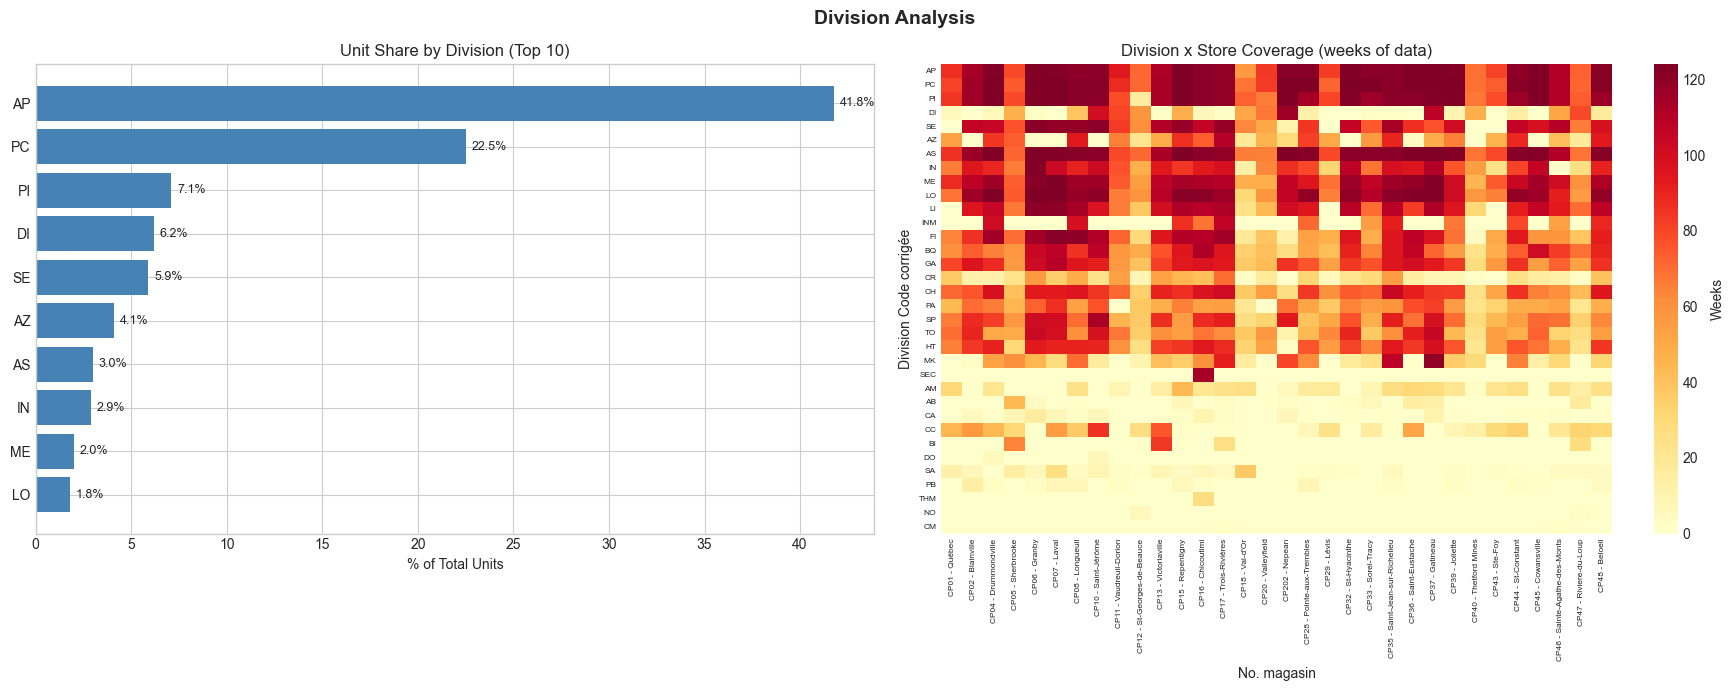

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 10 divisions bar chart
top10 = div_summary.head(10)
axes[0].barh(top10['Division Code corrigée'][::-1], top10['pct_units'][::-1], color='steelblue')
axes[0].set_xlabel('% of Total Units')
axes[0].set_title('Unit Share by Division (Top 10)')
for i, (pct, div) in enumerate(zip(top10['pct_units'][::-1], top10['Division Code corrigée'][::-1])):
    axes[0].text(pct + 0.3, i, f'{pct}%', va='center', fontsize=9)

# Division x Store heatmap — which stores carry which divisions?
div_store_counts = (
    raw.groupby(['Division Code corrigée', 'No. magasin'])['week_ending']
    .nunique().reset_index(name='n_weeks')
)
pivot = div_store_counts.pivot_table(
    index='Division Code corrigée', columns='No. magasin', values='n_weeks', fill_value=0
)
# Sort by total volume
div_order = div_summary['Division Code corrigée'].tolist()
pivot = pivot.reindex(div_order)

sns.heatmap(pivot, cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Weeks'},
            xticklabels=True, yticklabels=True)
axes[1].set_title('Division x Store Coverage (weeks of data)')
axes[1].tick_params(axis='both', labelsize=6)

plt.suptitle('Division Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'division_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5 — Units vs Revenue: Client Decision Point

The slice exports contain **units only** (`Quantité facturée`). However, the full
transaction table (`Exemple_Table_Vente.csv`) includes revenue and pricing data.

This section shows what revenue data is available so the client can decide whether
to forecast units, revenue, or both.

---

In [50]:
# ── Load a sample of the full transaction table ────────────────────────────────
vente_path = PROJECT_ROOT / 'data' / 'Exemple_Table_Vente.csv'
if vente_path.exists():
    vente_sample = pd.read_csv(vente_path, nrows=200, encoding='utf-8-sig')
    
    print('=== Exemple_Table_Vente.csv — Available Columns ===')
    print(f'Total columns: {len(vente_sample.columns)}')
    for i, col in enumerate(vente_sample.columns):
        print(f'  {i+1:2d}. {col}')
    
    # Show the key revenue columns
    revenue_cols = ['No. magasin', 'Division Code', 'Date de Vente',
                    'Quantité facturée', 'Prix de vente unitaire',
                    'Escompte en %', 'Montant de la ligne']
    available_cols = [c for c in revenue_cols if c in vente_sample.columns]
    
    if available_cols:
        print(f'\n=== Revenue Data Sample (first 10 rows) ===')
        # Use 'No. magasin corrigé' if 'No. magasin' doesn't have store codes
        display_cols = []
        for c in revenue_cols:
            if c in vente_sample.columns:
                display_cols.append(c)
            elif c == 'No. magasin' and 'No. magasin corrigé' in vente_sample.columns:
                display_cols.append('No. magasin corrigé')
        print(vente_sample[display_cols].head(10).to_string(index=False))
        
        if 'Montant de la ligne' in vente_sample.columns:
            print(f'\nRevenue column stats (sample):')
            rev = pd.to_numeric(vente_sample['Montant de la ligne'], errors='coerce')
            print(f'  Mean revenue per line: ${rev.mean():,.2f}')
            print(f'  Median: ${rev.median():,.2f}')
            print(f'  Min: ${rev.min():,.2f}, Max: ${rev.max():,.2f}')
else:
    print(f'File not found: {vente_path}')
    print('Revenue data not available for preview.')

print(f'\n{"=" * 60}')
print(f'DECISION POINT FOR CLIENT')
print(f'{"=" * 60}')
print(f'''
Current status: Forecasting UNITS only (from slice exports).

Option A — Units only (inventory planning):
  Stable metric, not affected by pricing changes.
  Best for: replenishment, warehouse planning, supply chain.

Option B — Revenue ($) only (financial planning):
  Captures pricing dynamics and discounting impact.
  Best for: budget forecasting, financial reporting.

Option C — Both units AND revenue:
  Most complete but doubles modeling effort.
  Requires re-exporting slices with "Montant de la ligne" column,
  OR joining against Exemple_Table_Vente.csv.

> CLIENT: Which do you need? If revenue, can we add it to slice exports?
''')

=== Exemple_Table_Vente.csv — Available Columns ===
Total columns: 29
   1. No. du franchisé
   2. No. de contrat
   3. Date du contrat
   4. No. de facture
   5. Date de la facture
   6. No. du client
   7. No. d'article
   8. No. fournisseur
   9. No. article fournisseur
  10. Description
  11. Division Code
  12. No. magasin
  13. Quantité facturée
  14. Prix de vente unitaire
  15. Escompte en %
  16. Montant escompte de la ligne
  17. Montant de la ligne
  18. Text2
  19. LogDate
  20. Premiers caractères
  21. Caisses ou Factures
  22. Date de Vente
  23. 2 premiers caractères
  24. Client magasin ou CP
  25. Formule Franchisés & Clients
  26. Meublex_Liste des clients CP.Code magasin
  27. _Client convertit
  28. No. magasin corrigé
  29. Code vendeur

=== Revenue Data Sample (first 10 rows) ===
No. magasin Division Code Date de Vente  Quantité facturée  Prix de vente unitaire  Escompte en %  Montant de la ligne
       CP48            AP      1-Jun-25                  1         

---
## Section 6 — Returns & Data Quality

### How returns are handled
- Negative `Quantité facturée` values = returned items
- At the weekly level: `units = sum(positive + negative)`, then clipped to 0
- We track `gross_units` (positive only), `returns` (absolute value of negatives), and `n_transactions` separately

### Why this matters for modeling
High return rates in certain divisions or stores may indicate data quality issues,
product problems, or seasonal return patterns that affect forecast accuracy.

---

In [51]:
total_positive = raw.loc[raw['Quantité facturée'] > 0, 'Quantité facturée'].sum()
total_negative = abs(raw.loc[raw['Quantité facturée'] < 0, 'Quantité facturée'].sum())
total_zero     = (raw['Quantité facturée'] == 0).sum()

print('=== Transaction-Level Data Quality ===')
print(f'Positive quantity rows : {(raw["Quantité facturée"] > 0).sum():,} ({total_positive:,.0f} units)')
print(f'Negative quantity rows : {(raw["Quantité facturée"] < 0).sum():,} ({total_negative:,.0f} units returned)')
print(f'Zero quantity rows     : {total_zero:,}')
print(f'Overall return rate    : {total_negative / total_positive * 100:.2f}% of units sold')

# Returns by division
print(f'\n=== Return Rate by Division (Top 10 by return volume) ===')
div_returns = (
    raw.groupby('Division Code corrigée')
       .agg(
           gross_units = ('Quantité facturée', lambda x: x[x > 0].sum()),
           return_units = ('Quantité facturée', lambda x: abs(x[x < 0].sum())),
       )
)
div_returns['return_rate_pct'] = (div_returns['return_units'] / div_returns['gross_units'] * 100).round(2)
div_returns = div_returns.sort_values('return_units', ascending=False)
print(div_returns.head(10).to_string())

# Returns by store
print(f'\n=== Return Rate by Store (Top 10 by return rate) ===')
store_returns = (
    raw.groupby('No. magasin')
       .agg(
           gross_units = ('Quantité facturée', lambda x: x[x > 0].sum()),
           return_units = ('Quantité facturée', lambda x: abs(x[x < 0].sum())),
       )
)
store_returns['return_rate_pct'] = (store_returns['return_units'] / store_returns['gross_units'] * 100).round(2)
store_returns = store_returns.sort_values('return_rate_pct', ascending=False)
print(store_returns.head(10).to_string())

# Nulls check
print(f'\n=== Missing Values ===')
null_counts = raw.isnull().sum()
nulls = null_counts[null_counts > 0]
if len(nulls) > 0:
    print(nulls.to_string())
else:
    print('No nulls in cleaned data.')

=== Transaction-Level Data Quality ===
Positive quantity rows : 197,650 (10,992,994 units)
Negative quantity rows : 2,644 (29,653 units returned)
Zero quantity rows     : 3,040
Overall return rate    : 0.27% of units sold

=== Return Rate by Division (Top 10 by return volume) ===
                        gross_units  return_units  return_rate_pct
Division Code corrigée                                            
AP                       4592335.62       8086.00             0.18
SE                        645661.19       4889.48             0.76
IN                        316575.74       2884.99             0.91
DI                        676355.18       2380.71             0.35
ME                        219159.50       2329.00             1.06
CH                         19152.00       1766.00             9.22
AZ                        455323.98       1392.00             0.31
PI                        778585.95        962.50             0.12
LI                         64953.50        675.00

---
## Section 7 — Weekly Aggregation (Target Variable)

Aggregate to **Week x Store x Division** — one row per group per week.
This is the primary output consumed by NB02 (Weather Integration).

---

In [52]:
weekly = (
    raw.groupby(['week_ending','No. magasin','city','province','Division Code corrigée'])
       .agg(
           units          = ('Quantité facturée', 'sum'),
           gross_units    = ('Quantité facturée', lambda x: x[x > 0].sum()),
           returns        = ('Quantité facturée', lambda x: abs(x[x < 0].sum())),
           n_transactions = ('Quantité facturée', 'count'),
           fiscal_year    = ('fiscal_year', 'first'),
           fiscal_week    = ('fiscal_week', 'first'),
       )
       .reset_index()
       .rename(columns={'No. magasin':'store_code', 'Division Code corrigée':'division_code'})
)

# Clip net units at 0
weekly['units'] = weekly['units'].clip(lower=0)

print(f'=== Weekly Aggregation Output ===')
print(f'Rows         : {len(weekly):,}')
print(f'Columns      : {list(weekly.columns)}')
print(f'Date range   : {weekly["week_ending"].min().date()} -> {weekly["week_ending"].max().date()}')
print(f'Unique weeks : {weekly["week_ending"].nunique()}')
print(f'Stores       : {weekly["store_code"].nunique()}')
print(f'Divisions    : {weekly["division_code"].nunique()}')
print(f'Groups       : {weekly.groupby(["store_code","division_code"]).ngroups}')
print(f'Fiscal years : {sorted(weekly["fiscal_year"].dropna().unique())}')
print(f'\nFiscal year breakdown:')
for fy in sorted(weekly['fiscal_year'].dropna().unique()):
    fy_data = weekly[weekly['fiscal_year'] == fy]
    nw = fy_data['week_ending'].nunique()
    status = 'complete' if nw >= 50 else 'partial'
    print(f'  FY{int(fy)}: {nw} weeks ({status}), {fy_data["units"].sum():,.0f} net units')

weekly.to_csv(DATA_PROCESSED / 'weekly_units.csv', index=False)
print(f'\nSaved: weekly_units.csv')
print(f'\nSample rows:')
weekly.head(10)

=== Weekly Aggregation Output ===
Rows         : 52,336
Columns      : ['week_ending', 'store_code', 'city', 'province', 'division_code', 'units', 'gross_units', 'returns', 'n_transactions', 'fiscal_year', 'fiscal_week']
Date range   : 2023-11-05 -> 2026-03-15
Unique weeks : 124
Stores       : 32
Divisions    : 34
Groups       : 777
Fiscal years : [np.int64(2024), np.int64(2025), np.int64(2026)]

Fiscal year breakdown:
  FY2024: 53 weeks (complete), 2,862,983 net units
  FY2025: 53 weeks (complete), 6,985,341 net units
  FY2026: 20 weeks (partial), 1,129,843 net units

Saved: weekly_units.csv

Sample rows:


,week_ending,store_code,city,province,division_code,units,gross_units,returns,n_transactions,fiscal_year,fiscal_week
0,2023-11-05,CP02 - Blainville,Blainville,QC,AP,62.0,62.0,0.0,3,2024,1
1,2023-11-05,CP02 - Blainville,Blainville,QC,AS,14.0,14.0,0.0,2,2024,1
2,2023-11-05,CP02 - Blainville,Blainville,QC,FI,1.0,1.0,0.0,1,2024,1
3,2023-11-05,CP02 - Blainville,Blainville,QC,GA,3.0,3.0,0.0,2,2024,1
4,2023-11-05,CP02 - Blainville,Blainville,QC,LI,1.0,1.0,0.0,1,2024,1
5,2023-11-05,CP02 - Blainville,Blainville,QC,LO,13.0,13.0,0.0,3,2024,1
6,2023-11-05,CP02 - Blainville,Blainville,QC,ME,1.0,1.0,0.0,1,2024,1
7,2023-11-05,CP02 - Blainville,Blainville,QC,PC,263.0,263.0,0.0,3,2024,1
8,2023-11-05,CP02 - Blainville,Blainville,QC,PI,183.0,183.0,0.0,3,2024,1
9,2023-11-05,CP02 - Blainville,Blainville,QC,SE,3.0,3.0,0.0,2,2024,1


---
## Section 8 — Seasonality & Demand Patterns

### Why this matters for the client
- Confirms the business expectation: pool/outdoor demand peaks in summer
- Year-over-year growth trends inform budget planning
- Division-level seasonal profiles guide inventory pre-positioning

---

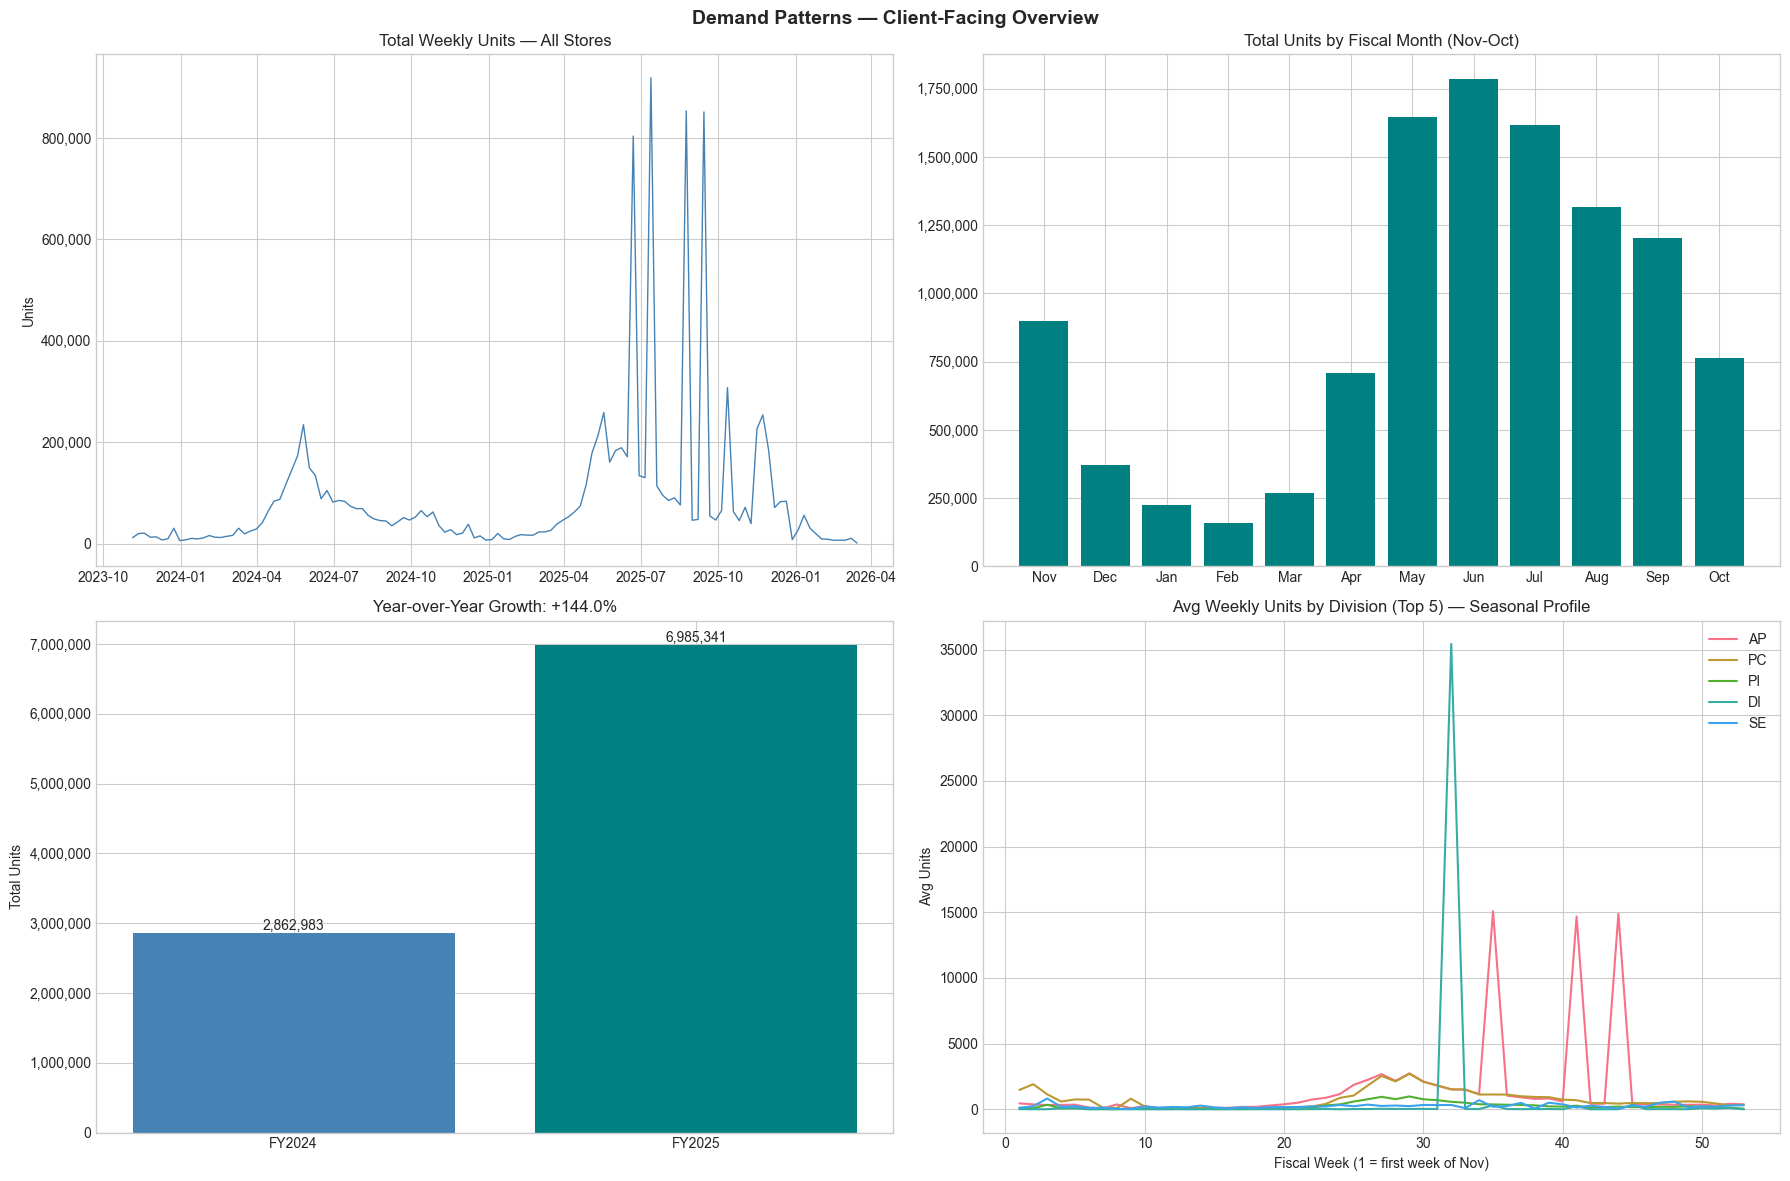

=== Fiscal Year Comparison ===
             total_units  avg_weekly_units  n_rows
fiscal_year                                       
2024           2862983.0             145.0   19798
2025           6985341.0             259.0   27022
2026           1129843.0             205.0    5516


In [53]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Weekly total units — all stores
weekly_total = weekly.groupby('week_ending')['units'].sum().sort_index()
axes[0,0].plot(weekly_total.index, weekly_total.values, color='steelblue', linewidth=1)
axes[0,0].set_title('Total Weekly Units — All Stores')
axes[0,0].set_ylabel('Units')
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))

# 2. Monthly seasonality (fiscal month order)
raw['month'] = raw['Date de Vente'].dt.month
month_units = raw.groupby('month')['Quantité facturée'].sum()
fiscal_month_units = month_units.reindex(FISCAL_MONTH_ORDER)
axes[0,1].bar(range(len(FISCAL_MONTH_ORDER)), fiscal_month_units.values, color='teal')
axes[0,1].set_title('Total Units by Fiscal Month (Nov-Oct)')
axes[0,1].set_xticks(range(len(FISCAL_MONTH_LABELS)))
axes[0,1].set_xticklabels(FISCAL_MONTH_LABELS)
axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))

# 3. Fiscal year comparison (FY2024 vs FY2025)
fy_compare = weekly.groupby('fiscal_year')['units'].agg(['sum','mean','count']).round(0)
fy_compare.columns = ['total_units', 'avg_weekly_units', 'n_rows']
complete_fys = fy_compare[fy_compare.index.isin([2024, 2025])]
if len(complete_fys) >= 2:
    growth = (complete_fys.loc[2025, 'total_units'] / complete_fys.loc[2024, 'total_units'] - 1) * 100
    bars = axes[1,0].bar(['FY2024', 'FY2025'],
                          [complete_fys.loc[2024, 'total_units'], complete_fys.loc[2025, 'total_units']],
                          color=['steelblue', 'teal'])
    axes[1,0].set_title(f'Year-over-Year Growth: {growth:+.1f}%')
    axes[1,0].set_ylabel('Total Units')
    axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))
    for bar, val in zip(bars, [complete_fys.loc[2024, 'total_units'], complete_fys.loc[2025, 'total_units']]):
        axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                       f'{val:,.0f}', ha='center', va='bottom', fontsize=10)

# 4. Top 5 divisions seasonal profile by fiscal week
top5_divs = weekly.groupby('division_code')['units'].sum().nlargest(5).index
div_weekly = weekly[weekly['division_code'].isin(top5_divs)].copy()
div_agg = div_weekly.groupby(['division_code', 'fiscal_week'])['units'].mean().reset_index()
for div in top5_divs:
    d = div_agg[div_agg['division_code'] == div].sort_values('fiscal_week')
    axes[1,1].plot(d['fiscal_week'], d['units'], label=div, linewidth=1.5)
axes[1,1].set_title('Avg Weekly Units by Division (Top 5) — Seasonal Profile')
axes[1,1].set_xlabel('Fiscal Week (1 = first week of Nov)')
axes[1,1].set_ylabel('Avg Units')
axes[1,1].legend()

plt.suptitle('Demand Patterns — Client-Facing Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'demand_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

# Fiscal year comparison table
print('=== Fiscal Year Comparison ===')
print(fy_compare.to_string())

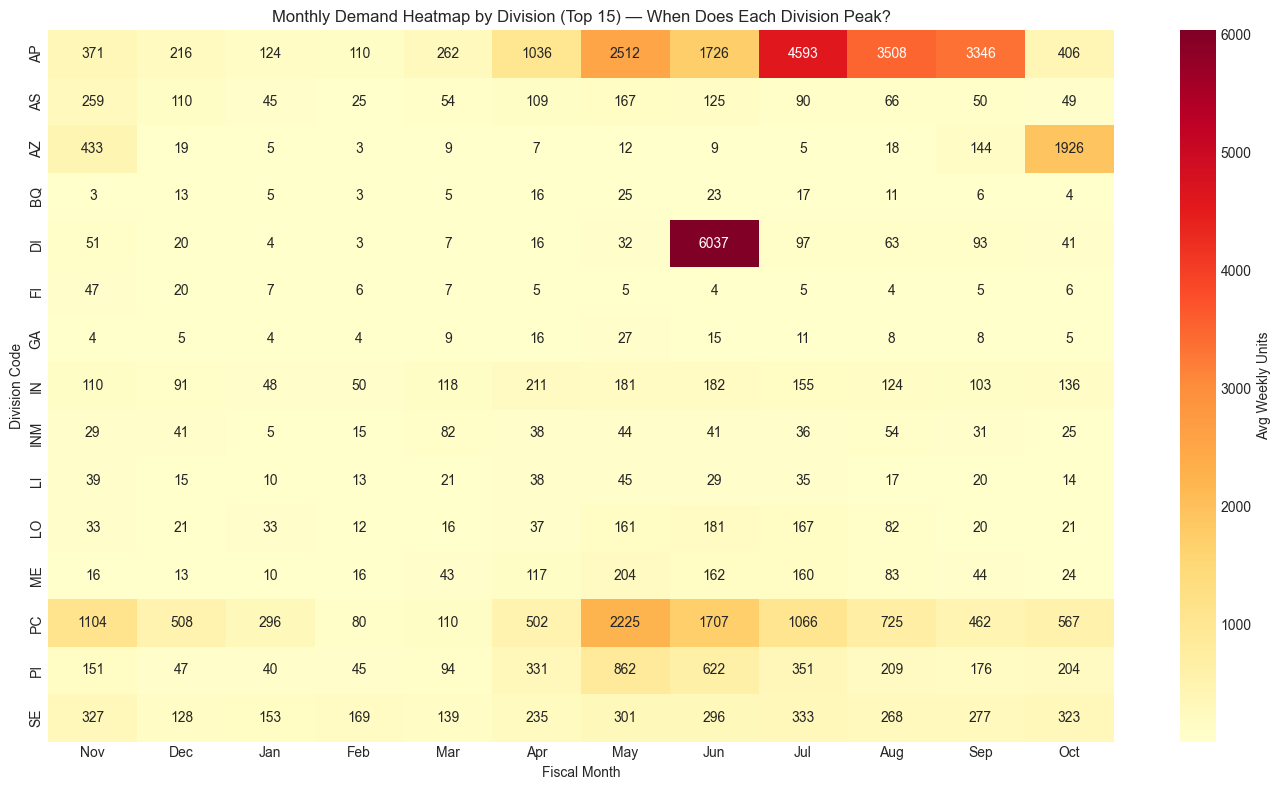

Insight: This heatmap shows which months each division is most active.
Divisions with narrow peaks (e.g., summer-only) need strong seasonal models.
Divisions with year-round demand can use simpler trend models.


In [54]:
# Monthly demand heatmap: Month x Division (when does each division peak?)
weekly_with_month = weekly.copy()
weekly_with_month['month'] = weekly_with_month['week_ending'].dt.month

top15_divs = weekly.groupby('division_code')['units'].sum().nlargest(15).index
heatmap_data = (
    weekly_with_month[weekly_with_month['division_code'].isin(top15_divs)]
    .groupby(['division_code', 'month'])['units']
    .mean()
    .unstack(fill_value=0)
)
# Reorder columns to fiscal month order
heatmap_data = heatmap_data.reindex(columns=FISCAL_MONTH_ORDER)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.0f', ax=ax,
            xticklabels=FISCAL_MONTH_LABELS,
            cbar_kws={'label': 'Avg Weekly Units'})
ax.set_title('Monthly Demand Heatmap by Division (Top 15) — When Does Each Division Peak?')
ax.set_ylabel('Division Code')
ax.set_xlabel('Fiscal Month')
plt.tight_layout()
plt.savefig(FIGURES / 'division_seasonality_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: This heatmap shows which months each division is most active.')
print('Divisions with narrow peaks (e.g., summer-only) need strong seasonal models.')
print('Divisions with year-round demand can use simpler trend models.')

---
## Section 9 — Panel Sparsity & Modeling Tiers

### Why this matters
The dataset is a panel: Store x Division x Week. Not every store carries every
product division, so the panel is inherently sparse. Understanding which groups
have sufficient data directly determines which forecasting approach to use.

---

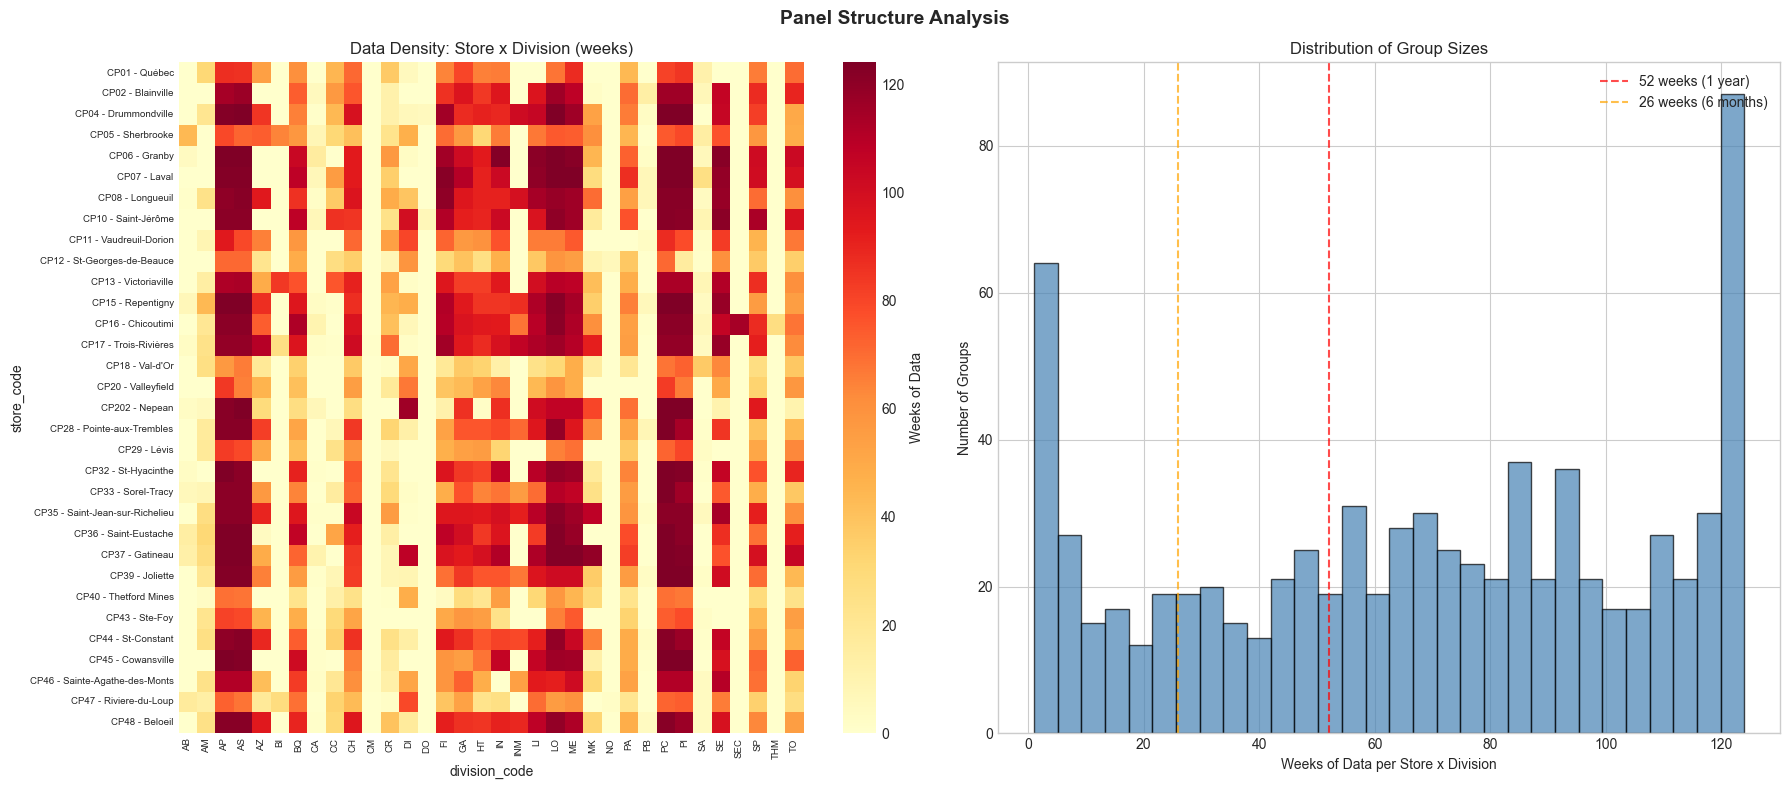

=== Panel Summary ===
Total groups (Store x Division): 777
Panel sparsity: 45.7%

=== Modeling Tier Recommendations ===

| Tier | Criteria      | Groups | %     | Recommended Model                      |
|------|---------------|--------|-------|----------------------------------------|
| A    | >= 52 weeks   |    508 | 65.4% | Full Prophet with annual seasonality   |
| B    | 26-51 weeks   |    115 | 14.8% | Simplified model, no YoY regressors    |
| C    | 10-25 weeks   |     63 |  8.1% | Aggregate with division/store medians  |
| D    | < 10 weeks    |     91 | 11.7% | Exclude — use division median baseline |



In [55]:
panel = (
    weekly.groupby(['store_code', 'division_code'])['week_ending']
    .nunique()
    .reset_index(name='n_weeks')
)

# Pivot for heatmap
pivot = panel.pivot_table(index='store_code', columns='division_code', values='n_weeks', fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(pivot, cmap='YlOrRd', ax=axes[0], cbar_kws={'label': 'Weeks of Data'},
            xticklabels=True, yticklabels=True)
axes[0].set_title('Data Density: Store x Division (weeks)')
axes[0].tick_params(axis='both', labelsize=7)

axes[1].hist(panel['n_weeks'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=52, color='red', linestyle='--', alpha=0.7, label='52 weeks (1 year)')
axes[1].axvline(x=26, color='orange', linestyle='--', alpha=0.7, label='26 weeks (6 months)')
axes[1].set_title('Distribution of Group Sizes')
axes[1].set_xlabel('Weeks of Data per Store x Division')
axes[1].set_ylabel('Number of Groups')
axes[1].legend()

plt.suptitle('Panel Structure Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'panel_structure.png', dpi=150, bbox_inches='tight')
plt.show()

total_groups = len(panel)
max_possible_weeks = weekly['week_ending'].nunique()
sparsity = 1 - (panel['n_weeks'].sum() / (total_groups * max_possible_weeks))

tier_52  = (panel['n_weeks'] >= 52).sum()
tier_26  = ((panel['n_weeks'] >= 26) & (panel['n_weeks'] < 52)).sum()
tier_10  = ((panel['n_weeks'] >= 10) & (panel['n_weeks'] < 26)).sum()
tier_low = (panel['n_weeks'] < 10).sum()

print(f'=== Panel Summary ===')
print(f'Total groups (Store x Division): {total_groups}')
print(f'Panel sparsity: {sparsity*100:.1f}%')
print(f'''
=== Modeling Tier Recommendations ===

| Tier | Criteria      | Groups | %     | Recommended Model                      |
|------|---------------|--------|-------|----------------------------------------|
| A    | >= 52 weeks   | {tier_52:>6} | {tier_52/total_groups*100:>4.1f}% | Full Prophet with annual seasonality   |
| B    | 26-51 weeks   | {tier_26:>6} | {tier_26/total_groups*100:>4.1f}% | Simplified model, no YoY regressors    |
| C    | 10-25 weeks   | {tier_10:>6} | {tier_10/total_groups*100:>4.1f}% | Aggregate with division/store medians  |
| D    | < 10 weeks    | {tier_low:>6} | {tier_low/total_groups*100:>4.1f}% | Exclude — use division median baseline |
''')

---
## Section 10 — Modeling Readiness Assessment

### Why this matters
This section answers: **Is each store x division series ready to be forecasted, and how?**

Key analyses:
1. **Intermittency classification** (Syntetos-Boylan ADI/CV²) — determines which model type to use
2. **Seasonality strength** — confirms whether seasonal models are appropriate
3. **Zero-demand patterns** — distinguishes seasonal zeros from structural zeros
4. **Lag signal validation** — justifies which lag features NB03 should create

This section feeds directly into NB04's model routing logic.

---

### 10a — Demand Intermittency Classification (Syntetos-Boylan)

Each store x division series is classified by two metrics:
- **ADI** (Average Demand Interval): How often does demand occur? ADI = total_periods / non_zero_periods
- **CV²** (Coefficient of Variation squared): How variable is non-zero demand?

| ADI <= 1.32 | ADI > 1.32 |
|------------|------------|
| **Smooth** (CV² <= 0.49) | **Intermittent** (CV² <= 0.49) |
| **Erratic** (CV² > 0.49) | **Lumpy** (CV² > 0.49) |

=== DEMAND REGIME CLASSIFICATION (Syntetos-Boylan) ===
Total series classified: 777

  smooth         : 165 series (21.2%)  -> Prophet (full)
  erratic        : 592 series (76.2%)  -> Prophet (wider CI)
  intermittent   :   7 series ( 0.9%)  -> Croston / monthly aggregation
  lumpy          :  13 series ( 1.7%)  -> Historical mean baseline


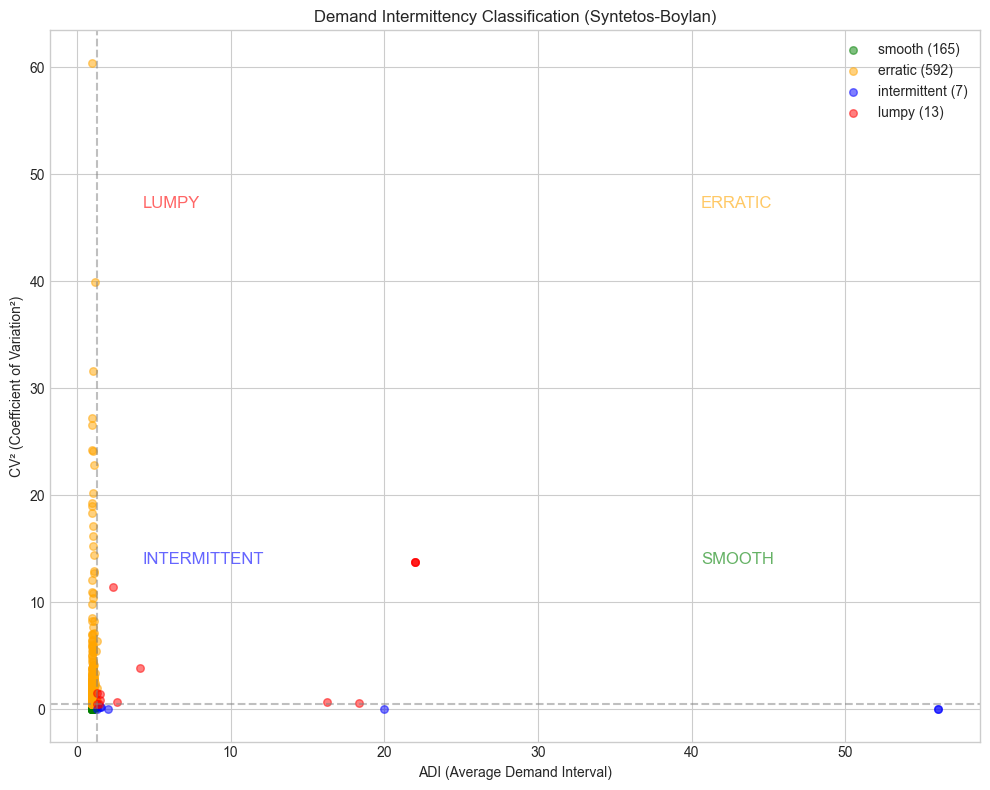


=== Regime Distribution by Division ===
regime         smooth  erratic  intermittent  lumpy  total
division_code                                             
SP                 23        9             0      0     32
CA                 17        1             0      1     19
SA                 15        7             2      0     24
PB                 14        0             0      0     14
AS                 13       19             0      0     32
CR                 11       19             0      0     30
AM                 10       13             0      0     23
CC                  9        7             3      4     23
MK                  9       15             0      1     25
HT                  5       23             1      3     32
DI                  5       19             0      1     25
BQ                  4       28             0      0     32
IN                  3       28             0      0     31
LI                  3       26             0      0     29
TO             

In [56]:
def classify_intermittency(series, adi_threshold=1.32, cv2_threshold=0.49):
    """
    Syntetos-Boylan ADI/CV² demand classification.
    Returns: (regime, ADI, CV2)
    """
    s = pd.Series(series).clip(lower=0).fillna(0)
    non_zero  = s[s > 0]
    n_total   = len(s)
    n_nonzero = len(non_zero)
    if n_nonzero == 0:
        return 'lumpy', np.inf, np.inf
    adi      = n_total / n_nonzero
    mean_nz  = non_zero.mean()
    std_nz   = non_zero.std(ddof=1) if len(non_zero) > 1 else 0.0
    cv2      = (std_nz / mean_nz) ** 2 if mean_nz > 0 else 0.0
    if   adi <= adi_threshold and cv2 <= cv2_threshold: regime = 'smooth'
    elif adi >  adi_threshold and cv2 <= cv2_threshold: regime = 'intermittent'
    elif adi <= adi_threshold and cv2 >  cv2_threshold: regime = 'erratic'
    else:                                                regime = 'lumpy'
    return regime, round(adi, 3), round(cv2, 3)

# Classify every Store x Division series
GROUP_COLS = ['store_code', 'city', 'division_code']

intermittency_records = []
for keys, group in weekly.groupby(GROUP_COLS):
    store, city, div = keys
    regime, adi, cv2 = classify_intermittency(group['units'])
    intermittency_records.append({
        'store_code': store, 'city': city, 'division_code': div,
        'regime': regime, 'ADI': adi, 'CV2': cv2,
        'n_weeks': len(group),
        'mean_units': round(group['units'].mean(), 2),
        'pct_zero': round((group['units'] == 0).mean() * 100, 1),
    })

intermittency_df = pd.DataFrame(intermittency_records)

# Summary
print('=== DEMAND REGIME CLASSIFICATION (Syntetos-Boylan) ===')
print(f'Total series classified: {len(intermittency_df)}')
print()

MODEL_MAP = {
    'smooth': 'Prophet (full)',
    'erratic': 'Prophet (wider CI)',
    'intermittent': 'Croston / monthly aggregation',
    'lumpy': 'Historical mean baseline'
}

regime_counts = intermittency_df['regime'].value_counts()
for regime in ['smooth', 'erratic', 'intermittent', 'lumpy']:
    n   = regime_counts.get(regime, 0)
    pct = n / len(intermittency_df) * 100
    print(f'  {regime:<14} : {n:3d} series ({pct:4.1f}%)  -> {MODEL_MAP[regime]}')

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = {'smooth': 'green', 'erratic': 'orange', 'intermittent': 'blue', 'lumpy': 'red'}
for regime in ['smooth', 'erratic', 'intermittent', 'lumpy']:
    subset = intermittency_df[intermittency_df['regime'] == regime]
    # Cap infinite values for plotting
    plot_adi = subset['ADI'].replace(np.inf, subset['ADI'][subset['ADI'] < np.inf].max() * 1.2 if (subset['ADI'] < np.inf).any() else 10)
    plot_cv2 = subset['CV2'].replace(np.inf, subset['CV2'][subset['CV2'] < np.inf].max() * 1.2 if (subset['CV2'] < np.inf).any() else 10)
    ax.scatter(plot_adi, plot_cv2, c=colors[regime], label=f'{regime} ({len(subset)})',
              alpha=0.5, s=30)

ax.axvline(x=1.32, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=0.49, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('ADI (Average Demand Interval)')
ax.set_ylabel('CV² (Coefficient of Variation²)')
ax.set_title('Demand Intermittency Classification (Syntetos-Boylan)')
ax.legend()
ax.text(0.7, 0.25, 'SMOOTH', fontsize=12, color='green', alpha=0.6, transform=ax.transAxes)
ax.text(0.7, 0.75, 'ERRATIC', fontsize=12, color='orange', alpha=0.6, transform=ax.transAxes)
ax.text(0.1, 0.25, 'INTERMITTENT', fontsize=12, color='blue', alpha=0.6, transform=ax.transAxes)
ax.text(0.1, 0.75, 'LUMPY', fontsize=12, color='red', alpha=0.6, transform=ax.transAxes)
plt.tight_layout()
plt.savefig(FIGURES / 'intermittency_classification.png', dpi=150, bbox_inches='tight')
plt.show()

# By division
print(f'\n=== Regime Distribution by Division ===')
div_regime = (
    intermittency_df.groupby(['division_code', 'regime']).size()
                    .unstack(fill_value=0)
                    .reindex(columns=['smooth','erratic','intermittent','lumpy'], fill_value=0)
)
div_regime['total'] = div_regime.sum(axis=1)
div_regime = div_regime.sort_values('smooth', ascending=False)
print(div_regime.to_string())

# Save
intermittency_df.to_csv(DATA_PROCESSED / 'demand_intermittency.csv', index=False)
print(f'\nSaved: demand_intermittency.csv')

### 10b — Seasonality Strength (Top 20 Series)

For the highest-volume store x division groups, we decompose the series with STL
and measure seasonal strength = Var(seasonal) / Var(seasonal + residual).

This tells us whether to use `multiplicative` vs `additive` seasonality in Prophet,
and which series have weak seasonality (may not benefit from seasonal models).

In [57]:
from statsmodels.tsa.seasonal import STL

# Top 20 groups by total volume with >= 52 weeks
group_totals = weekly.groupby(['store_code','division_code']).agg(
    total_units=('units','sum'), n_weeks=('week_ending','nunique')
).reset_index()
top_groups = (
    group_totals[group_totals['n_weeks'] >= 52]
    .nlargest(20, 'total_units')
)

seasonality_results = []
for _, row in top_groups.iterrows():
    store, div = row['store_code'], row['division_code']
    series = (
        weekly[(weekly['store_code'] == store) & (weekly['division_code'] == div)]
        .set_index('week_ending')['units']
        .sort_index()
        .asfreq('W-SUN')
        .fillna(0)
    )
    if len(series) < 52:
        continue
    try:
        stl = STL(series, period=52, robust=True)
        result = stl.fit()
        seasonal_var = result.seasonal.var()
        residual_var = result.resid.var()
        total_var = seasonal_var + residual_var
        strength = seasonal_var / total_var if total_var > 0 else 0
        
        # Check multiplicative vs additive: if seasonal amplitude scales with level
        level = result.trend
        ratio = (result.seasonal / level.replace(0, np.nan)).dropna()
        ratio_cv = ratio.std() / abs(ratio.mean()) if abs(ratio.mean()) > 0 else np.inf
        mode = 'multiplicative' if ratio_cv < 1.5 else 'additive'
        
        seasonality_results.append({
            'store_code': store, 'division_code': div,
            'seasonal_strength': round(strength, 3),
            'suggested_mode': mode,
            'total_units': int(row['total_units']),
        })
    except Exception:
        pass

if seasonality_results:
    seas_df = pd.DataFrame(seasonality_results).sort_values('seasonal_strength', ascending=False)
    print('=== Seasonality Strength (Top 20 Series by Volume) ===')
    print(f'Seasonal strength = Var(seasonal) / Var(seasonal + residual)')
    print(f'Values close to 1.0 = strong seasonality; close to 0 = weak\n')
    print(seas_df.to_string(index=False))
    
    avg_strength = seas_df['seasonal_strength'].mean()
    mode_counts = seas_df['suggested_mode'].value_counts()
    print(f'\nAverage seasonal strength: {avg_strength:.3f}')
    print(f'Suggested modes: {mode_counts.to_dict()}')
    print(f'\nRecommendation for NB04: Use {mode_counts.idxmax()} seasonality as default.')
else:
    print('Not enough data for seasonality decomposition.')

=== Seasonality Strength (Top 20 Series by Volume) ===
Seasonal strength = Var(seasonal) / Var(seasonal + residual)
Values close to 1.0 = strong seasonality; close to 0 = weak

                     store_code division_code  seasonal_strength suggested_mode  total_units
          CP36 - Saint-Eustache            PC              1.000       additive        93744
            CP10 - Saint-Jérôme            PI              1.000       additive       130980
                  CP06 - Granby            PC              1.000       additive       101309
CP35 - Saint-Jean-sur-Richelieu            PC              1.000       additive       110753
                CP37 - Gatineau            PC              1.000       additive       130536
                  CP06 - Granby            IN              0.999       additive       226489
CP35 - Saint-Jean-sur-Richelieu            AP              0.998       additive       120755
                CP37 - Gatineau            AP              0.997       additive

### 10c — Zero-Demand Patterns

Distinguishing **seasonal zeros** (pool divisions in winter) from **structural zeros**
(division not carried by the store) helps determine whether zeros should be modeled
as part of the seasonal pattern or excluded from the series.

In [58]:
# Zero-demand analysis by division
zero_analysis = (
    weekly.groupby('division_code')
    .agg(
        total_weeks   = ('units', 'count'),
        zero_weeks    = ('units', lambda x: (x == 0).sum()),
        mean_units    = ('units', 'mean'),
    )
)
zero_analysis['pct_zero'] = (zero_analysis['zero_weeks'] / zero_analysis['total_weeks'] * 100).round(1)
zero_analysis = zero_analysis.sort_values('pct_zero', ascending=False)

print('=== Zero-Demand Weeks by Division ===')
print(zero_analysis.to_string())

# Seasonal zeros: check if zeros cluster in winter months (Nov-Mar)
weekly_with_month = weekly.copy()
weekly_with_month['month'] = weekly_with_month['week_ending'].dt.month
weekly_with_month['is_winter'] = weekly_with_month['month'].isin([11, 12, 1, 2, 3])

zero_by_season = (
    weekly_with_month[weekly_with_month['units'] == 0]
    .groupby('is_winter').size()
)
total_zeros = weekly_with_month['units'].eq(0).sum()
if total_zeros > 0:
    winter_zeros = zero_by_season.get(True, 0)
    summer_zeros = zero_by_season.get(False, 0)
    print(f'\nZero-demand weeks: {total_zeros:,} total')
    print(f'  Winter (Nov-Mar): {winter_zeros:,} ({winter_zeros/total_zeros*100:.1f}%)')
    print(f'  Non-winter (Apr-Oct): {summer_zeros:,} ({summer_zeros/total_zeros*100:.1f}%)')
    if winter_zeros / total_zeros > 0.6:
        print(f'  -> Zeros are predominantly seasonal (winter). Models should capture this.')
    else:
        print(f'  -> Zeros are spread across seasons. Some may be structural (division not carried).')

=== Zero-Demand Weeks by Division ===
               total_weeks  zero_weeks   mean_units  pct_zero
division_code                                                
CC                     730         212     2.100000      29.0
THM                     27           6     2.037037      22.2
HT                    2165         221     6.200462      10.2
SA                     169          14     2.473373       8.3
DI                     975          76   693.171590       7.8
MK                    1150          75     8.635652       6.5
CR                     812          51    25.053387       6.3
AB                     116           6    21.540948       5.2
SEC                    114           5    31.995175       4.4
AM                     483          17     6.030021       3.5
CA                      87           3    25.183908       3.4
PA                    1625          45    10.482462       2.8
IN                    2445          62   128.595603       2.5
TO                    1926      

### 10d — Lag Signal Validation (PACF on Top Series)

NB03 creates lag features (1w, 2w, 4w, 8w, 52w). This section validates
which lags actually carry predictive signal using PACF analysis on high-volume series.

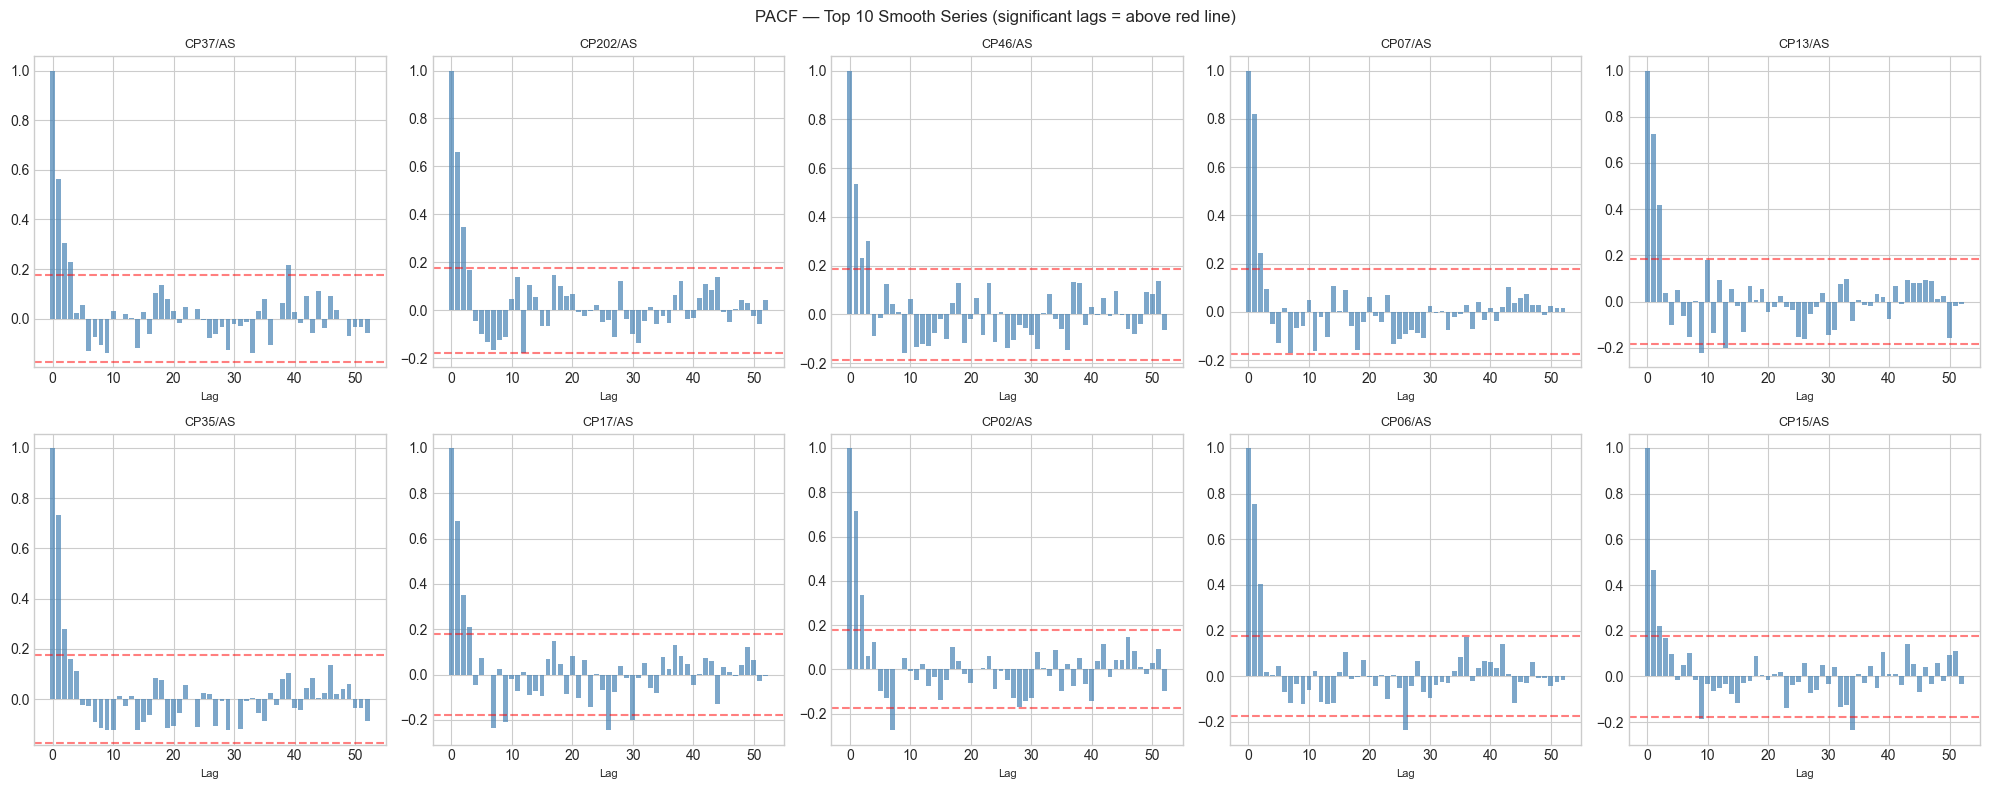

=== PACF Results — Significant Lags ===
store div significant_lags  pacf_lag1  pacf_lag4  pacf_lag52
 CP37  AS           [1, 2]      0.562      0.023      -0.057
CP202  AS           [1, 2]      0.661     -0.045       0.044
 CP46  AS           [1, 2]      0.536     -0.089      -0.062
 CP07  AS           [1, 2]      0.820     -0.050       0.017
 CP13  AS       [1, 2, 13]      0.726     -0.099      -0.011
 CP35  AS           [1, 2]      0.734      0.113      -0.086
 CP17  AS       [1, 2, 26]      0.676     -0.048      -0.006
 CP02  AS           [1, 2]      0.715      0.124      -0.097
 CP06  AS       [1, 2, 26]      0.756      0.006      -0.015
 CP15  AS           [1, 2]      0.467      0.099      -0.035

Lag significance frequency (out of 10 series):
  Lag  1w: 10/10 series (100%)
  Lag  2w: 10/10 series (100%)
  Lag  4w: 0/10 series (0%)
  Lag  8w: 0/10 series (0%)
  Lag 13w: 1/10 series (10%)
  Lag 26w: 2/10 series (20%)
  Lag 52w: 0/10 series (0%)

Recommendation for NB03: Focus on la

In [59]:
from statsmodels.tsa.stattools import pacf

# Top 10 smooth series with >= 52 weeks
smooth_series = intermittency_df[
    (intermittency_df['regime'] == 'smooth') & (intermittency_df['n_weeks'] >= 52)
].nlargest(10, 'mean_units')

target_lags = [1, 2, 4, 8, 13, 26, 52]  # NB03 lag candidates
lag_results = []

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, (_, row) in enumerate(smooth_series.iterrows()):
    store, div = row['store_code'], row['division_code']
    series = (
        weekly[(weekly['store_code'] == store) & (weekly['division_code'] == div)]
        .set_index('week_ending')['units']
        .sort_index()
        .asfreq('W-SUN')
        .fillna(0)
    )
    if len(series) < 53:
        continue
    
    try:
        max_lag = min(52, len(series) // 2 - 1)
        pacf_vals = pacf(series, nlags=max_lag, method='ywm')
        
        # Record significant lags
        conf_bound = 1.96 / np.sqrt(len(series))
        sig_lags = [l for l in target_lags if l <= max_lag and abs(pacf_vals[l]) > conf_bound]
        lag_results.append({
            'store': store.split(' - ')[0], 'div': div,
            'significant_lags': sig_lags,
            'pacf_lag1': round(pacf_vals[1], 3) if 1 <= max_lag else None,
            'pacf_lag4': round(pacf_vals[4], 3) if 4 <= max_lag else None,
            'pacf_lag52': round(pacf_vals[min(52, max_lag)], 3),
        })
        
        if idx < 10:
            axes[idx].bar(range(max_lag + 1), pacf_vals[:max_lag + 1], color='steelblue', alpha=0.7)
            axes[idx].axhline(y=conf_bound, color='red', linestyle='--', alpha=0.5)
            axes[idx].axhline(y=-conf_bound, color='red', linestyle='--', alpha=0.5)
            axes[idx].set_title(f'{store.split(" - ")[0]}/{div}', fontsize=9)
            axes[idx].set_xlabel('Lag', fontsize=8)
    except Exception:
        pass

plt.suptitle('PACF — Top 10 Smooth Series (significant lags = above red line)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / 'pacf_top_series.png', dpi=150, bbox_inches='tight')
plt.show()

if lag_results:
    lag_df = pd.DataFrame(lag_results)
    print('=== PACF Results — Significant Lags ===')
    print(lag_df.to_string(index=False))
    
    # Count how often each lag is significant
    from collections import Counter
    all_sig = [l for r in lag_results for l in r['significant_lags']]
    lag_freq = Counter(all_sig)
    print(f'\nLag significance frequency (out of {len(lag_results)} series):')
    for lag in sorted(target_lags):
        freq = lag_freq.get(lag, 0)
        print(f'  Lag {lag:2d}w: {freq}/{len(lag_results)} series ({freq/len(lag_results)*100:.0f}%)')
    
    print(f'\nRecommendation for NB03: Focus on lags that are significant in >50% of series.')
    print(f'Lags with low significance can be dropped to reduce feature dimensionality.')

---
## Section 11 — Questions for Client

The following questions emerged from this EDA and need client input before
proceeding with the forecasting model. They are organized by priority.

---

### Data Completeness

1. **Missing stores**: 7 retail stores from Table_Magasins have no slice data:
   - CP03 (Brossard), CP21 (Rimouski), CP23 (Terrebonne), CP31 (Pierrefonds)
   - CP41 (St-Hubert), CP49 (Bonaventure), CP50 (Rouyn-Noranda)
   - **Are slice exports available for these?** Are they active stores?

2. **Uneven store coverage**: Some stores have significantly fewer weeks of data than others.
   - **Are these newer stores (opened mid-period)?** Or is it a POS/Power BI export issue?
   - Specifically: CP05 (Sherbrooke), CP20 (Valleyfield), CP40 (Thetford Mines)

### Division Codes

3. **Division mapping**: The 34 division codes are internal ERP identifiers (e.g., AP, FI, PC).
   - **Please provide a mapping** of these codes to product line names.
   - Which divisions are active product lines vs internal/obsolete codes?

4. **Division grouping**: Which divisions should be grouped together for forecasting?
   - Example groupings we hypothesize: Pool-related (PC, CH, LO?), Outdoor (ME, GA, BQ?), Fitness (FI, CR?)
   - **Please confirm or correct** these groupings.

### Scope & Objectives

5. **Units vs Revenue**: Currently forecasting **units only**. Revenue data exists in the full transaction table.
   - Do you need **unit forecasts** (inventory planning), **revenue forecasts** (financial planning), or both?
   - If revenue is needed, can we add `Montant de la ligne` to slice exports?

6. **Forecast horizon**: What is the primary planning horizon?
   - 4 weeks (short-term tactical)?
   - 8 weeks (medium-term operational)?
   - 13 weeks / 1 quarter (strategic)?

### Business Context

7. **Store changes**: Are there planned store openings, closures, renovations, or relocations in the next 12 months?

8. **Promotion calendar**: We observe unexplained demand spikes in the data.
   - Is there a **promotion calendar** we can integrate? (Sales events, in-store promotions, flyer drops)
   - This would significantly improve forecast accuracy.

9. **Supply constraints**: Are there inventory or installation capacity constraints that would **cap demand** even if the forecast is higher? (e.g., limited pool installation crews in peak season)

10. **Inventory data**: `Exemple_Table_Inventaire.xlsx` has stock levels. Should inventory constraints be factored into the forecast (e.g., flagging stockout risk)?

---
## Appendix A — Technical Diagnostics

The following analyses are included for technical completeness but do not directly
drive modeling decisions in the current pipeline. They are preserved for reference
and audit purposes.

---

### A.1 — Stationarity Tests (ADF & KPSS)

These test whether the aggregate weekly demand series has a unit root (non-stationary).

**Note**: Prophet handles non-stationarity internally via its trend component,
so these tests do not change the modeling approach. They are included for documentation.

In [60]:
from statsmodels.tsa.stattools import adfuller, kpss

weekly_total_series = weekly.groupby('week_ending')['units'].sum().sort_index()

# ADF Test
adf_result = adfuller(weekly_total_series.dropna(), autolag='AIC')
print('=== Augmented Dickey-Fuller Test ===')
print(f'  Test statistic: {adf_result[0]:.4f}')
print(f'  p-value:        {adf_result[1]:.4f}')
print(f'  Lags used:      {adf_result[2]}')
print(f'  Conclusion:     {"Stationary" if adf_result[1] < 0.05 else "Non-stationary"} (alpha=0.05)')

# KPSS Test
kpss_result = kpss(weekly_total_series.dropna(), regression='ct', nlags='auto')
print(f'\n=== KPSS Test (trend) ===')
print(f'  Test statistic: {kpss_result[0]:.4f}')
print(f'  p-value:        {kpss_result[1]:.4f}')
print(f'  Conclusion:     {"Stationary" if kpss_result[1] > 0.05 else "Non-stationary"} (alpha=0.05)')

print(f'\n[Technical note: Prophet models trend internally — these tests are for documentation only.]')

=== Augmented Dickey-Fuller Test ===
  Test statistic: -2.0334
  p-value:        0.2721
  Lags used:      11
  Conclusion:     Non-stationary (alpha=0.05)

=== KPSS Test (trend) ===
  Test statistic: 0.1810
  p-value:        0.0231
  Conclusion:     Non-stationary (alpha=0.05)

[Technical note: Prophet models trend internally — these tests are for documentation only.]


### A.2 — Aggregate ACF / PACF

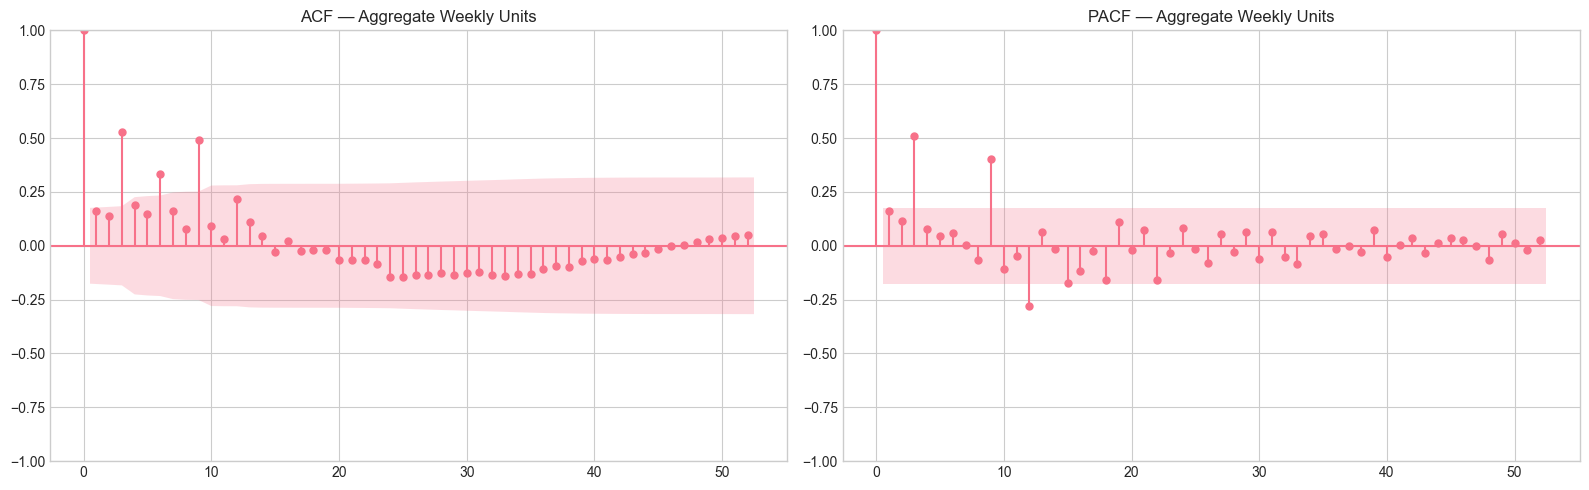

[Technical note: Per-series PACF in Section 10d is more actionable than this aggregate view.]


In [61]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
n_weeks = len(weekly_total_series)
max_lags = min(52, n_weeks // 2 - 1)
plot_acf(weekly_total_series.dropna(), lags=max_lags, ax=axes[0], title='ACF — Aggregate Weekly Units')
plot_pacf(weekly_total_series.dropna(), lags=max_lags, ax=axes[1], title='PACF — Aggregate Weekly Units', method='ywm')
plt.tight_layout()
plt.savefig(FIGURES / 'acf_pacf_aggregate.png', dpi=150, bbox_inches='tight')
plt.show()

print('[Technical note: Per-series PACF in Section 10d is more actionable than this aggregate view.]')

### A.3 — Target Distribution & Outlier Detection

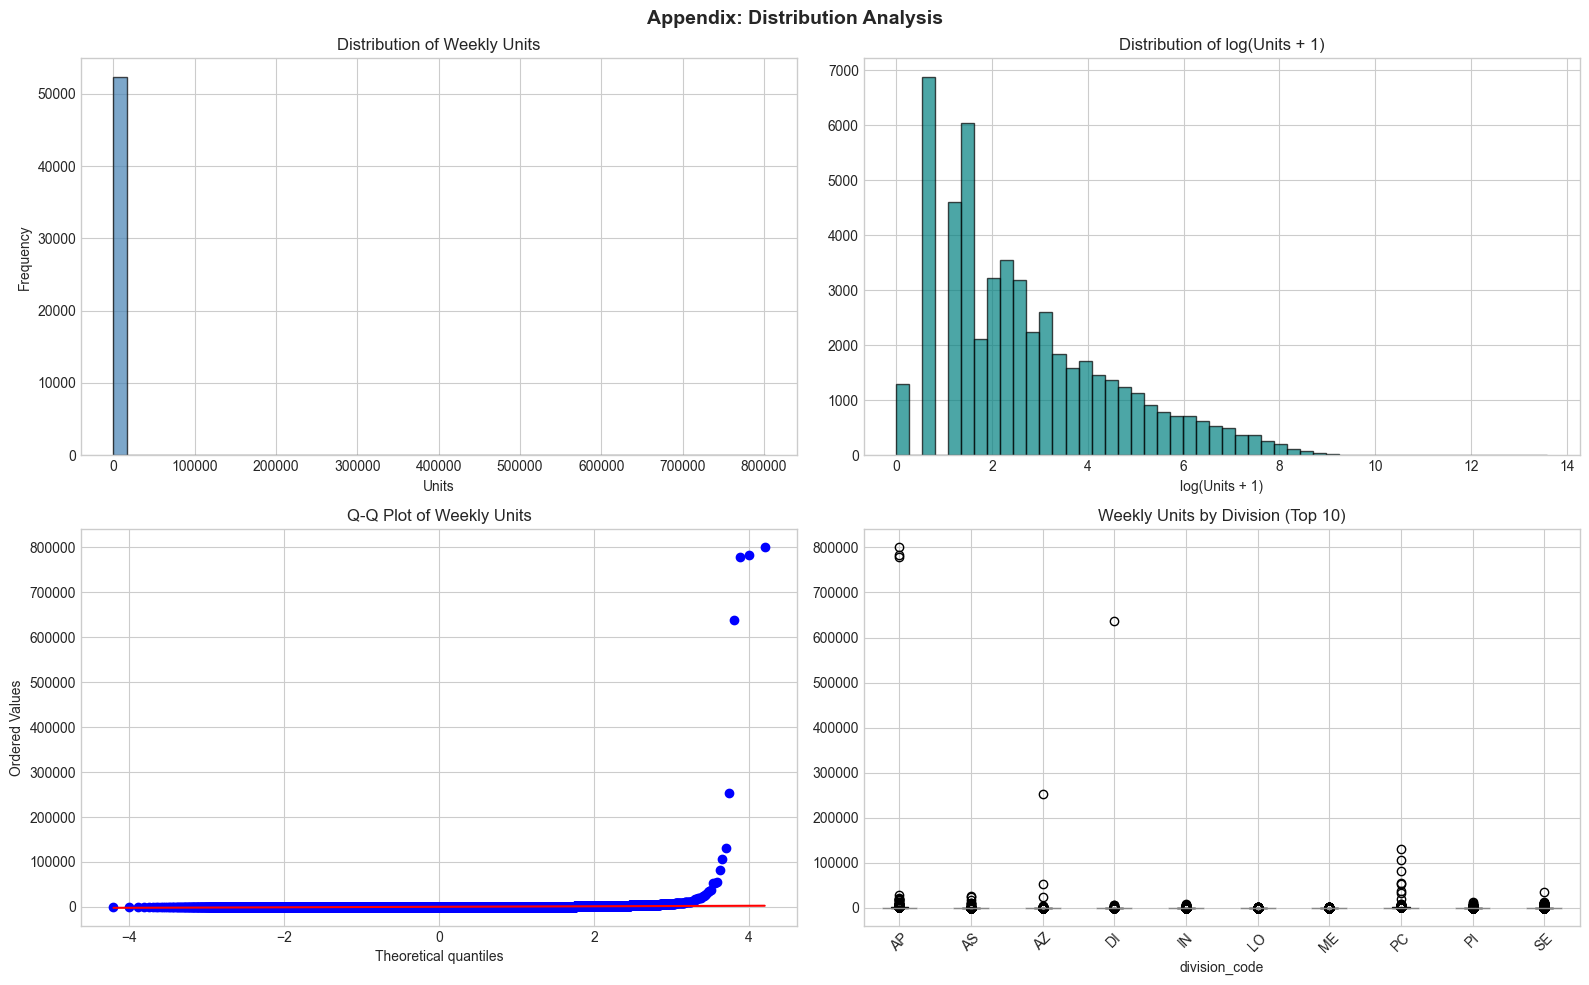

Skewness:  107.564
Kurtosis:  12055.204
Log skew:  0.921
Log kurt:  0.356
Zero-unit weeks: 1,290 (2.5%)

IQR outliers: 3,103 of 52,336 rows (5.9%)
[Note: Outliers are flagged but NOT removed — they may represent promotions or seasonal surges.]


In [62]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Distribution
axes[0,0].hist(weekly['units'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0,0].set_title('Distribution of Weekly Units')
axes[0,0].set_xlabel('Units'); axes[0,0].set_ylabel('Frequency')

# Log-transformed
log_units = np.log1p(weekly['units'])
axes[0,1].hist(log_units, bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[0,1].set_title('Distribution of log(Units + 1)')
axes[0,1].set_xlabel('log(Units + 1)')

# Q-Q plot
scipy_stats.probplot(weekly['units'].dropna(), dist='norm', plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot of Weekly Units')

# Box plots by top 10 divisions
top10_divs = weekly.groupby('division_code')['units'].sum().nlargest(10).index
box_data = weekly[weekly['division_code'].isin(top10_divs)]
box_data.boxplot(column='units', by='division_code', ax=axes[1,1], rot=45)
axes[1,1].set_title('Weekly Units by Division (Top 10)')
axes[1,1].get_figure().suptitle('')

plt.suptitle('Appendix: Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'distribution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Skewness:  {weekly["units"].skew():.3f}')
print(f'Kurtosis:  {weekly["units"].kurtosis():.3f}')
print(f'Log skew:  {log_units.skew():.3f}')
print(f'Log kurt:  {log_units.kurtosis():.3f}')
print(f'Zero-unit weeks: {(weekly["units"] == 0).sum():,} ({(weekly["units"] == 0).mean()*100:.1f}%)')

# IQR outlier detection
def flag_iqr_outliers(group):
    q1 = group['units'].quantile(0.25)
    q3 = group['units'].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    group['is_outlier'] = ((group['units'] < lower) | (group['units'] > upper)).astype(int)
    return group

weekly_flagged = weekly.groupby(['store_code', 'division_code'], group_keys=False).apply(flag_iqr_outliers)
n_outliers = weekly_flagged['is_outlier'].sum()
print(f'\nIQR outliers: {n_outliers:,} of {len(weekly_flagged):,} rows ({n_outliers/len(weekly_flagged)*100:.1f}%)')
print(f'[Note: Outliers are flagged but NOT removed — they may represent promotions or seasonal surges.]')

### A.4 — STL Decomposition (Aggregate)

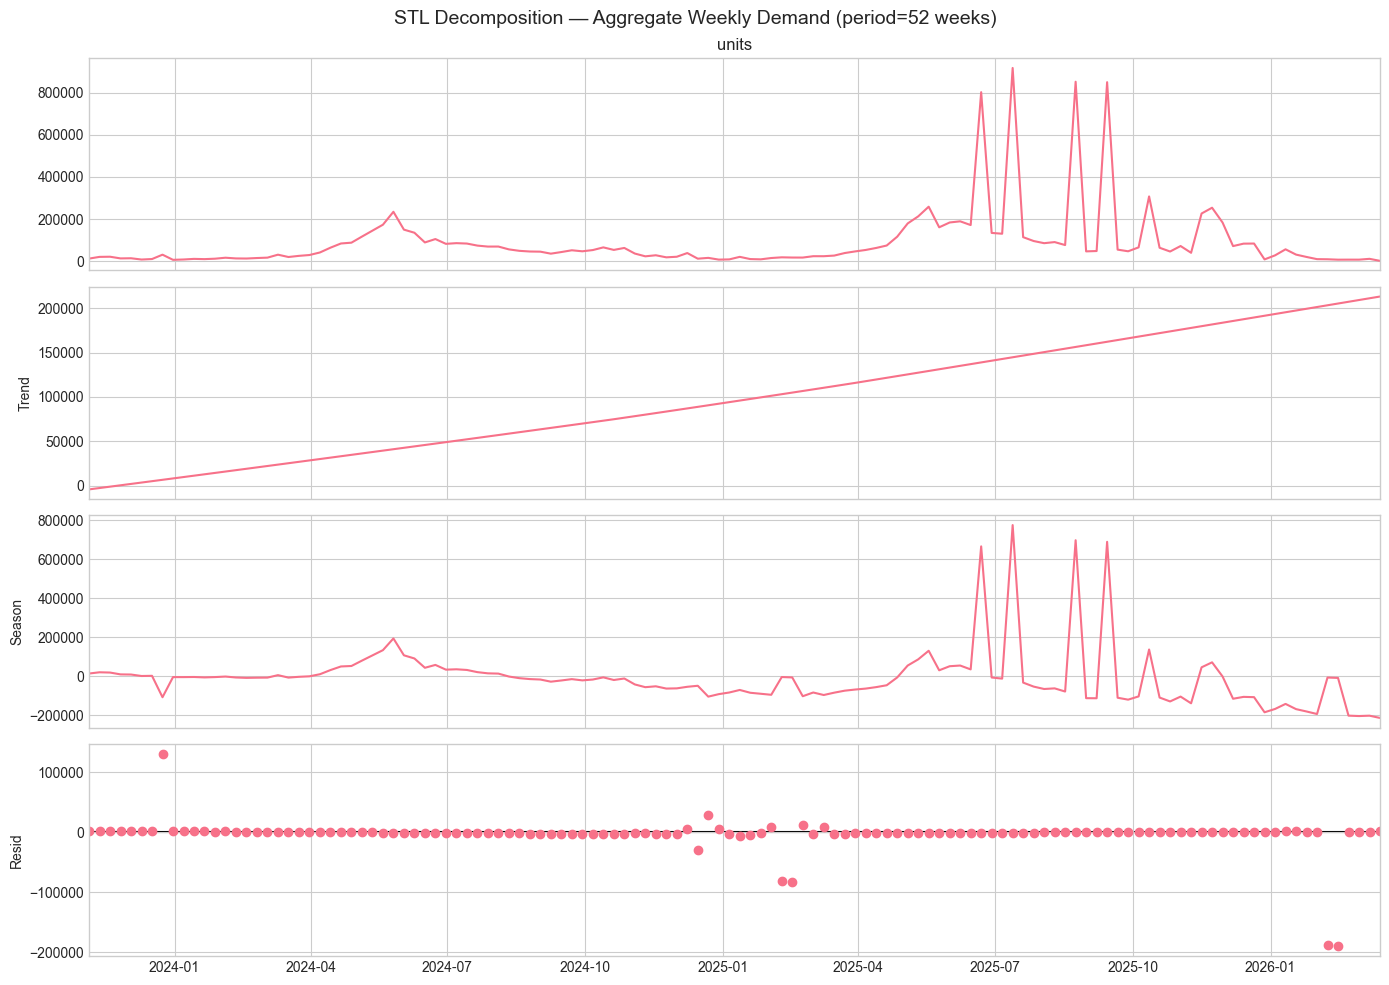

[Technical note: Per-series STL in Section 10b is more actionable than this aggregate decomposition.]


In [63]:
weekly_total_series_clean = weekly_total_series.dropna()
n_weeks = len(weekly_total_series_clean)
stl_period = min(52, n_weeks // 2)

if n_weeks >= stl_period * 2:
    stl = STL(weekly_total_series_clean, period=stl_period, robust=True)
    result = stl.fit()
    fig = result.plot()
    fig.set_size_inches(14, 10)
    fig.suptitle(f'STL Decomposition — Aggregate Weekly Demand (period={stl_period} weeks)', fontsize=14)
    plt.tight_layout()
    plt.savefig(FIGURES / 'stl_decomposition.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'Not enough data for STL decomposition (need {stl_period*2} weeks, have {n_weeks})')

print('[Technical note: Per-series STL in Section 10b is more actionable than this aggregate decomposition.]')

---
## Next Steps

- **NB02 — Weather Integration**: Merge city-level weather data onto `weekly_units.csv`
- **NB03 — Feature Engineering**: Seasonality (Fourier), lags (validated in Section 10d), weather interactions, holiday flags
- **NB04 — Forecasting Model**: Prophet / XGBoost per store x division group, using intermittency classification from Section 10a

### Key decisions from this EDA that feed downstream:
1. **Intermittency regimes** (`demand_intermittency.csv`) → NB04 model routing
2. **Modeling tiers** (Section 9) → NB04 minimum history thresholds
3. **Seasonality mode** (Section 10b) → NB04 Prophet `seasonality_mode` parameter
4. **Significant lags** (Section 10d) → NB03 lag feature selection